## set up the grid


In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
import matplotlib.colors as mcolors

In [3]:
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT
from create_aste90_layers import bin_3d_term_to_TS,create_TS_mesh

In [4]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001_r8_07May2026_pfe/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [5]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [9]:
_T_edges_raw

array([-4., -3., -2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.,
       20., 22., 24., 26., 28., 30., 32., 34., 36., 38., 60., 70.])

In [10]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

nT = 150
nS = 150

#T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
#S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS
T_edges = _T_edges_raw
S_edges = _S_edges_raw
boundsT,boundsS = T_edges,S_edges
nT,nS = 24,24

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Sbin3,Tbin3 = Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1]    # this is now correct, should be same placement as edges but -1 on both ends

In [11]:
print(Sbin2.shape,Sbin3.shape)

(23, 23) (21, 21)


In [12]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [13]:
# load the mask in 1D to get the points from offline

# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)
ind2d = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1
# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan
ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

# load the indices for layers
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [14]:
# iwet_mine.shape
# plt.pcolormesh(mymsk)

## Create a sample plot of the gates with depth

In [15]:
# these are the indices we want to read from, but not write to
# at y = 186, we want -ADVy
x_bsoh = np.array([54, 54, 54, 54, 54])
x_bsov = np.array([0,  1,  2,  3,  4,  5,  6,  7,  8,  9])    # from Norway to Sp
y_bsoh = np.array([145, 146, 147, 148, 149])
y_bsov = np.array([186, 186, 186, 186, 186, 186, 186, 186, 186, 186])    # from Norway to Sp

x_spfjh = np.array([20,20,20,23,24,24,26,26])    # vertical gates from Sp to Fj as -x
y_spfjh = np.array([185,184,183,182,181,180,179,178])
x_spfjv = np.array([20,21,22,23,24,25,26])          # horizontal gates where we want to read -y
y_spfjv = np.array([183,183,183,183,182,180,180])

y_fjnzv = np.arange(165,175,1)
x_fjnzv = np.full_like(y_fjnzv,27)    # horizontal gate where we want to read -x

y_nzruv = np.arange(152,155,1)
x_nzruv = np.full_like(y_nzruv,12)   # horizontal gate where we want to read -x

# gates_mask starts as NaN everywhere
gates_mask = np.full((ny, nx), np.nan, dtype=float)


# import numpy as np

# gates_mask starts as NaN everywhere
gates_mask = np.full((ny, nx), np.nan, dtype=float)

# ---- BSO ----
# bsoh: read -y, so mark at y-1
gates_mask[y_bsoh , x_bsoh] = 1

# bsov: no shift mentioned here
gates_mask[y_bsov-1, x_bsov] = 1

# ---- Sp-Fj ----
# spfjh: read -x, so mark at x-1
gates_mask[y_spfjh, x_spfjh ] = 2

# spfjv: read -y, so mark at y-1
gates_mask[y_spfjv , x_spfjv] = 2

# ---- Fj-NZ ----
# fjnzv: read -x, so mark at x-1
gates_mask[y_fjnzv, x_fjnzv] = 3

# ---- NZ-RU ----
# nzruv: read -x, so mark at x-1
gates_mask[y_nzruv, x_nzruv-1] = 4

In [16]:
# plt.pcolormesh(gates_mask)

In [17]:
# plt.pcolormesh(get_aste_tracer(gates_mask,nfx,nfy)[0])
# plt.xlim(140,180)
# plt.ylim(140,200)

In [18]:
# --- Bathymetry Colormap ---
colors = ['#7fcce0', '#3f479b', '#544596', '#534694', '#754898', '#9b4696', '#bd4896',
          '#d13b8d', '#e50f7c', '#e4034b', '#e3030e', '#e11108', '#e34b05', '#f18901',
          '#fcc903', '#f5e707', '#cfd600', '#a2c60e', '#7ebc20', '#6fb528', '#72b628', '#74bd6b']
bounds = [0, 10, 20, 30, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300,
          400, 500, 750, 1000, 1500, 2000, 4000, 6000]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

In [19]:
landmsk = np.zeros((ny,nx))
landmsk[np.isnan(mygrid['hFacC'][0])] = 1
land_dataf3 = get_aste_faces(landmsk,nfx,nfy).f3[0]
land_dataf3[land_dataf3==0]  = np.nan

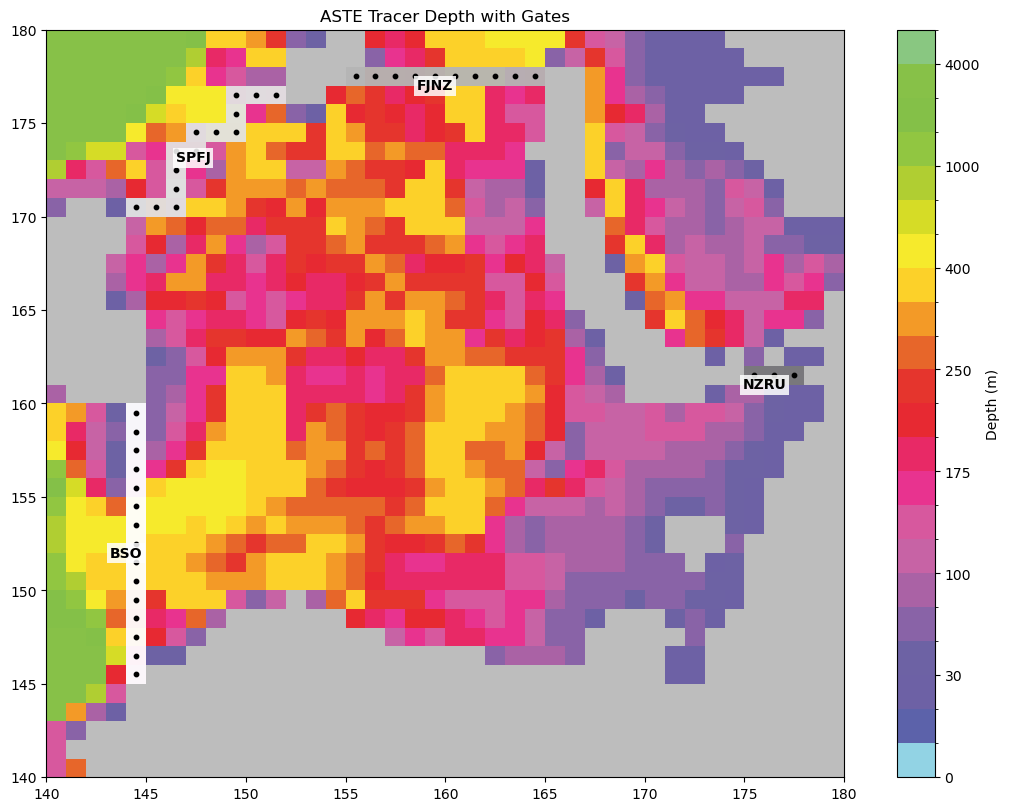

In [20]:
# ----------------------------
# Convert to ASTE tracer layout
# ----------------------------
depth_tr = get_aste_tracer(mygrid["Depth"], nfx, nfy)[0]
land_tr  = get_aste_tracer(landmsk, nfx, nfy)[0]
gates_tr = get_aste_tracer(gates_mask, nfx, nfy)[0]

land_tr = land_tr.astype(float)
land_tr[land_tr == 0] = np.nan


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(10, 8), constrained_layout=True)

ax.set_title("ASTE Tracer Depth with Gates")

# Background depth
pc = ax.pcolormesh(depth_tr, cmap=cmap, norm=norm, alpha=0.85)

# Land overlay
ax.pcolormesh(land_tr, cmap="Greys", vmin=-2, vmax=6)

# Gate overlay
# mask NaNs so only gate cells are drawn
gates_plot = np.ma.masked_invalid(gates_tr)
pg = ax.pcolormesh(gates_plot, cmap="Greys", vmin=1, vmax=6, alpha=0.95)

cbar = fig.colorbar(pc, ax=ax)
cbar.set_label("Depth (m)")


# ----------------------------
# Label gates at their approximate centers
# ----------------------------
gate_info = [
    ("BSO", 1),
    ("SPFJ", 2),
    ("FJNZ", 3),
    ("NZRU", 4),
]

for label, val in gate_info:
    yy, xx = np.where(gates_tr == val)
    if len(xx) > 0:
        xc = xx.mean()
        yc = yy.mean()

        ax.text(
            xc,
            yc,
            label,
            color="k",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2),
        )

        # optional: mark all individual gate cells
        ax.scatter(xx + 0.5, yy + 0.5, c="k", s=10)


# Optional zoom
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)

plt.savefig("gates_on_tracer_depth.png", dpi=300, bbox_inches="tight")
plt.show()

## calculate eq. 1--3 and walkthrough

In [21]:
# load the LAYERS diagnostics
dt = 1800 # single time step

In [22]:
ffac=1e-6
G_T=np.array([])
metaT=parsemeta(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[1] + ".meta")
nFldsT = metaT["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
fldsIwant = np.array(['LaTh2TH','LaTz2TH'])

# check for the correct diagnostics
metaT['fldList']   # 13, 14, 15, 16, 19, 22
b = metaT['fldList']
ifldT = np.array([1,2])    # surf, hDiff, vDiff, hADV, vADV, total tend
# print(np.array(b)[ifldT])  # for G_T

# remake the following to look for the existing terms and see if we can recreate
# ['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
ifldT = np.array([0,1,2,7,8,11])
print(np.array(b)[ifldT])  # for G_T


# we will just do the exact same thing for all the terms
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[1] + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setStend=nFldsS.copy()

# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

24
['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [23]:
# make a key of names to use

namekeyT = {}
namesT = np.array(["tend","ADVr","ADVh","DFrT","DFhT","surf"])
namesT = np.flip(namesT)
for i in range(len(ifldT)-1, -1, -1):
    termname = setTtend[ifldT[i]]
    namekeyT[termname] = namesT[i]

namekeyS = {}
namesS = np.array(["tend","ADVr","ADVh","DFrS","DFhS","surf"])
namesS = np.flip(namesS)
for i in range(len(ifldS)-1, -1, -1):
    termname = setTtend[ifldS[i]]
    namekeyS[termname] = namesS[i]

# namesT

In [24]:
# load G_T and G_S for this specific point online
name = "BarentsS"
ts = tsstr[1]

# -----------------------
# G_T
# -----------------------
G_T = {}
G_T[name] = {}
G_T[name][ts] = {}          # layer-space results, shape (nT-1,)
G_T[name]["map"] = {}
G_T[name]["map"][ts] = {}   # map-space results, shape (ny, nx)

for i in range(len(ifldT)-1, -1, -1):
    termname = setTtend[ifldT[i]]

    tmp = read_float64_skip(
        layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data",
        nx * ny * (nT-1),
        ifldT[i]
    )
    tmp = np.reshape(tmp, (nT-1, nx*ny))

    # if you want only the Barents Sea contribution, mask here too
    tmp = tmp * mymsk_1dtile * (rac2dtile * hf2dtile)   # * ffac

    if i == ifldT.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residT = tmp.copy()
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residT = residT - tmp

    # 1) layer-space result: shape (nT-1,)
    a = np.nansum(tmp[:, iwet_mine], axis=1)
    G_T[name][ts][namekeyT[termname]] = a

    # 2) horizontal map result: shape (ny, nx)
    amap = np.full(nx * ny, np.nan)
    amap[iwet_mine] = np.nansum(tmp[:, iwet_mine], axis=0)
    amap = amap.reshape((ny, nx), order='C')
    G_T[name]["map"][ts][namekeyT[termname]] = amap


# -----------------------
# G_S
# -----------------------
metaS = parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + "0000000003" + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setTtend = nFldsT.copy()

# check for the correct diagnostics
b = metaS['fldList']
ifldS = np.array([12, 13, 14, 19, 20, 23])

print(np.array(b)[ifldS])  # for G_S

G_S = {}
G_S[name] = {}
G_S[name][ts] = {}          # layer-space results, shape (nS-1,)
G_S[name]["map"] = {}
G_S[name]["map"][ts] = {}   # map-space results, shape (ny, nx)

for i in range(len(ifldS)-1, -1, -1):
    termname = setTtend[ifldS[i]]

    tmp = read_float64_skip(
        layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[-1] + ".data",
        nx * ny * (nS-1),
        ifldS[i]
    )
    tmp = np.reshape(tmp, (nS-1, nx*ny))

    # multiply by the Barents Sea mask and weights
    tmp = tmp * mymsk_1dtile * (rac2dtile * hf2dtile)   # * ffac

    if i == ifldS.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residS = tmp.copy()
    else:
        # remove from residual
        residS = residS - tmp

    # 1) layer-space result: shape (nS-1,)
    a = np.nansum(tmp[:, iwet_mine], axis=1)
    G_S[name][ts][namekeyS[termname]] = a

    # 2) horizontal map result: shape (ny, nx)
    amap = np.full(nx * ny, np.nan)
    amap[iwet_mine] = np.nansum(tmp[:, iwet_mine], axis=0)
    amap = amap.reshape((ny, nx), order='C')
    G_S[name]["map"][ts][namekeyS[termname]] = amap

24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


### Load the offline version

In [26]:
# load the G_S and G_T for offline for the same column in the package
from create_aste90_layers import create_layers_totalTHETA, create_layers_totalSALT

dt = 1800

MsumT, dF_Tnew = create_layers_totalTHETA(
    tsstr, mygrid, myparms, dirdiags, dirstate, layers_path,
    mymsk, nz, ny, nx, nfx, nfy, dt, boundsT, boundsS,
    mapping=False, debug=False
)

MsumS, dF_Snew = create_layers_totalSALT(
    tsstr, mygrid, myparms, dirdiags, dirstate, layers_path,
    mymsk, nz, ny, nx, nfx, nfy, dt, boundsT, boundsS,
    mapping=False, debug=False
)

# dF_Tnew and dF_Snew are now dictionaries, not arrays.
# In the new THETA code, the keys are:
# ADVh, ADVr, DFhT, DFrT, TFLUX, zconv_top, swtop, KPP, tend

T_labels = ["ADVh", "ADVr", "DFhT", "DFrT", "TFLUX", "zconv_top", "swtop", "KPP"]
T_tend_label = "tend"

print("THETA budget terms:")
for lab in T_labels:
    print(lab, np.nansum(dF_Tnew[lab] / dT_centers), "m^3/s")

print()
print("sum non-tendency:", np.nansum([dF_Tnew[lab] / dT_centers for lab in T_labels]), "m^3/s")
print("tendency:", np.nansum(dF_Tnew[T_tend_label] / dT_centers), "m^3/s")
print("residual:", np.nansum([dF_Tnew[lab] / dT_centers for lab in T_labels]) 
                   - np.nansum(dF_Tnew[T_tend_label] / dT_centers), "m^3/s")
print()


# Salt budget: use whatever keys create_layers_totalSALT now returns.
# If it mirrors the THETA structure, likely names are something like:
# ADVh, ADVr, DFhS, DFrS, SFLUX, KPP, tend
# Adjust these labels to exactly match dF_Snew.keys().

print("Available SALT keys:", dF_Snew.keys())

S_labels = [k for k in dF_Snew.keys() if k != "tend"]
S_tend_label = "tend"

print("SALT budget terms:")
for lab in S_labels:
    print(lab, np.nansum(dF_Snew[lab] / dS_centers), "m^3/s")

print()
print("sum non-tendency:", np.nansum([dF_Snew[lab] / dS_centers for lab in S_labels]), "m^3/s")
print("tendency:", np.nansum(dF_Snew[S_tend_label] / dS_centers), "m^3/s")
print("residual:", np.nansum([dF_Snew[lab] / dS_centers for lab in S_labels])
                   - np.nansum(dF_Snew[S_tend_label] / dS_centers), "m^3/s")

THETA budget terms:
ADVh 5676417.119034225 m^3/s
ADVr 242826.00594013464 m^3/s
DFhT 6174.655459172358 m^3/s
DFrT 4272358.396806877 m^3/s
TFLUX -15372856.8158255 m^3/s
zconv_top -15372856.8158255 m^3/s
swtop 0.0 m^3/s
KPP 96486.35530712735 m^3/s

sum non-tendency: -20451451.099103466 m^3/s
tendency: -5078594.283278929 m^3/s
residual: -15372856.815824537 m^3/s

Available SALT keys: dict_keys(['ADVh', 'ADVr', 'DFhS', 'DFrS', 'surf', 'zconv_top', 'sptop', 'KPP', 'tend'])
SALT budget terms:
ADVh -2199843.2821398056 m^3/s
ADVr 2.3283064365386963e-10 m^3/s
DFhS 605.8847470848075 m^3/s
DFrS -2.7284841053187847e-12 m^3/s
surf 37589.6543275386 m^3/s
zconv_top 28486.17563373148 m^3/s
sptop 9103.478693807127 m^3/s
KPP -2.9132252166164108e-12 m^3/s

sum non-tendency: -2124058.0887376433 m^3/s
tendency: -2170751.221777122 m^3/s
residual: 46693.13303947868 m^3/s


In [23]:
print(np.nansum(dF_Tnew[0]))
print(np.nansum(MsumT['Msum']))  ##/np.nansum(dT_centers)) 
# in degC.m^3/s

print()

print(np.nansum(dF_Snew[0]))
print(np.nansum(MsumS['Msum']))  ##/np.nansum(dT_centers))
# in degC.m^3/s

11126757.315022953
11126757.315022953

-4392889.650053527
-4392889.650053528


In [24]:
# instead of the following, which may be unclear, I think it would be better to plot just the terms
# and the residual for the layers at each temperature or salt
# G_T['BarentsS'][ts]['ADVh']

In [45]:
# # make a new plot that leaves things as surface, advh, internal, gates, and total tend
# internalGT_on = G_T['BarentsS'][ts]['LTza2TH'] + G_T['BarentsS'][ts]['LaTh2TH'] + G_T['BarentsS'][ts]['LaTz2TH']
# surfGT_on = G_T['BarentsS'][ts]['LaTs2TH']
# advhGT_on = G_T['BarentsS'][ts]['LTha2TH']
# tendGT_on = internalGT_on + surfGT_on + advhGT_on

# internalGS_on = G_S['BarentsS'][ts]['LTza1SLT'] + G_S['BarentsS'][ts]['LaTh1SLT'] + G_S['BarentsS'][ts]['LaTz1SLT']
# surfGS_on = G_S['BarentsS'][ts]['LaTs1SLT']
# advhGS_on = G_S['BarentsS'][ts]['LTha1SLT']
# tendGS_on = internalGS_on + surfGS_on + advhGS_on

# int_idxs = np.array([1,2,3,5])
# internalGT_off = np.nansum(dF_Tnew[int_idxs],axis=0)/binwidthT1
# surfGT_off = dF_Tnew[4]/binwidthT1
# advhGT_off = dF_Tnew[0]/binwidthT1
# tendGT_off = internalGT_off + advhGT_off + surfGT_off

# internalGS_off = np.nansum(dF_Snew[int_idxs],axis=0)/binwidthS1
# surfGS_off = dF_Snew[4]/binwidthS1
# advhGS_off = dF_Snew[0]/binwidthS1
# tendGS_off = internalGS_off + advhGS_off + surfGS_off

# make a new plot that leaves things as surface, advh, internal, gates, and total tend
surfGT_on = G_T['BarentsS'][ts]['surf']
advhGT_on = G_T['BarentsS'][ts]['ADVh']
advrGT_on = G_T['BarentsS'][ts]['ADVr']
dfhGT_on  = G_T['BarentsS'][ts]['DFhT']
dfrGT_on  = G_T['BarentsS'][ts]['DFrT']
tendGT_on = G_T['BarentsS'][ts]['tend']
internalGT_on = advrGT_on + dfhGT_on + dfrGT_on

surfGS_on = G_S['BarentsS'][ts]['surf']
advhGS_on = G_S['BarentsS'][ts]['ADVh']
advrGS_on = G_S['BarentsS'][ts]['ADVr']
dfhGS_on  = G_S['BarentsS'][ts]['DFhS']
dfrGS_on  = G_S['BarentsS'][ts]['DFrS']
tendGS_on = G_S['BarentsS'][ts]['tend']
internalGS_on = advrGS_on + dfhGS_on + dfrGS_on


int_idxs = np.array([1,2,3,5])
internalGT_off = np.nansum(dF_Tnew[int_idxs],axis=0)/binwidthT1
surfGT_off = dF_Tnew[4]/binwidthT1
advhGT_off = dF_Tnew[0]/binwidthT1
advrGT_off = dF_Tnew[1]/binwidthT1
dfhGT_off = dF_Tnew[2]/binwidthT1
dfrGT_off = dF_Tnew[3]/binwidthT1
kppGT_off = dF_Tnew[5]/binwidthT1
tendGT_off = internalGT_off + advhGT_off + surfGT_off

internalGS_off = np.nansum(dF_Snew[int_idxs],axis=0)/binwidthS1
surfGS_off = dF_Snew[4]/binwidthS1
advhGS_off = dF_Snew[0]/binwidthS1
advrGS_off = dF_Snew[1]/binwidthS1
dfhGS_off = dF_Snew[2]/binwidthS1
dfrGS_off = dF_Snew[3]/binwidthS1
kppGS_off = dF_Snew[5]/binwidthS1
tendGS_off = internalGS_off + advhGS_off + surfGS_off



In [46]:
G_T['BarentsS'][ts].keys()

dict_keys(['tend', 'ADVr', 'ADVh', 'DFrT', 'DFhT', 'surf'])

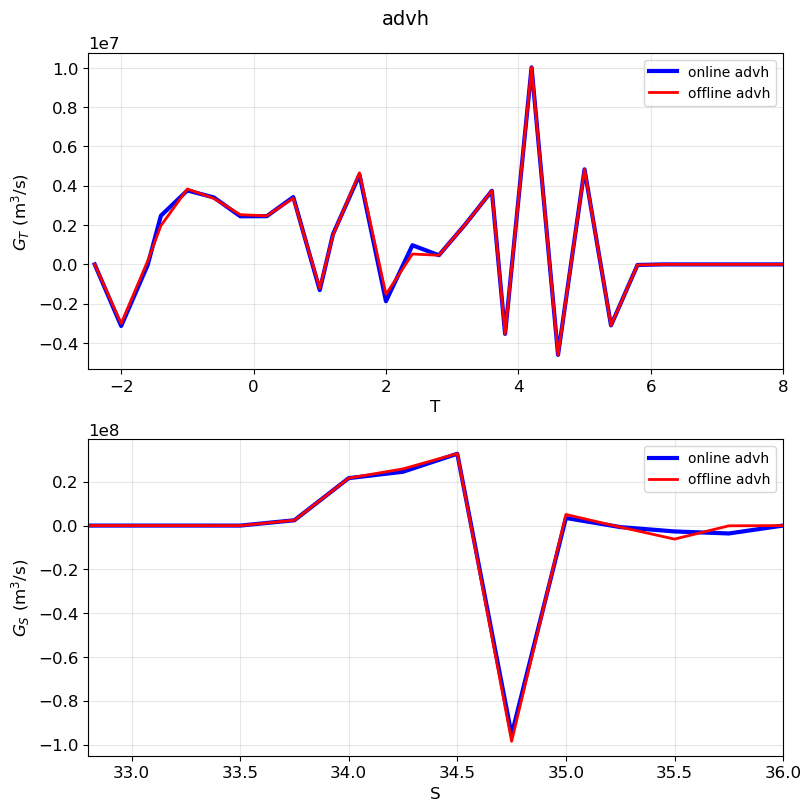

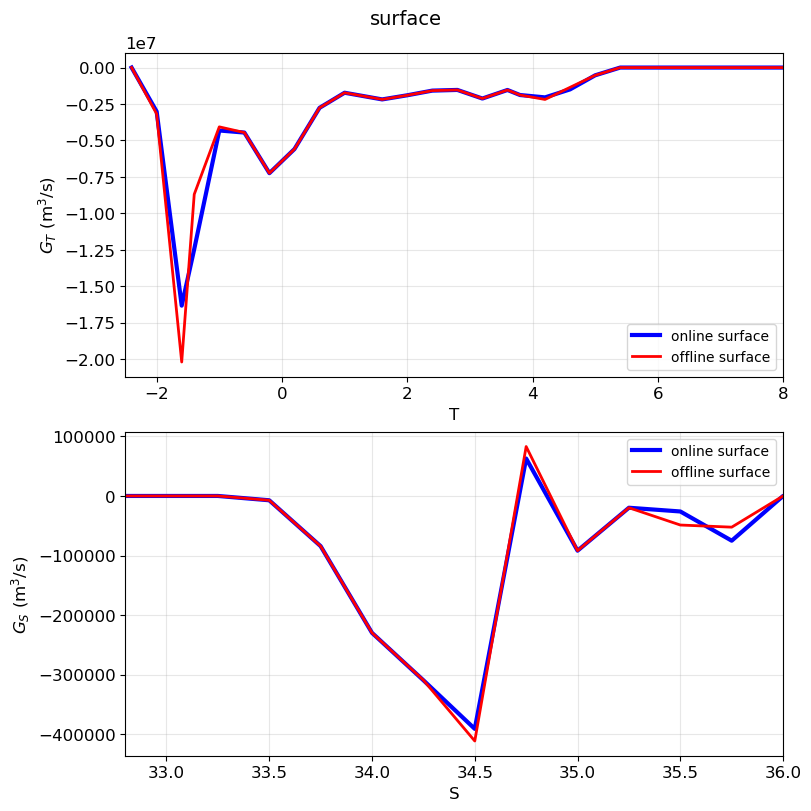

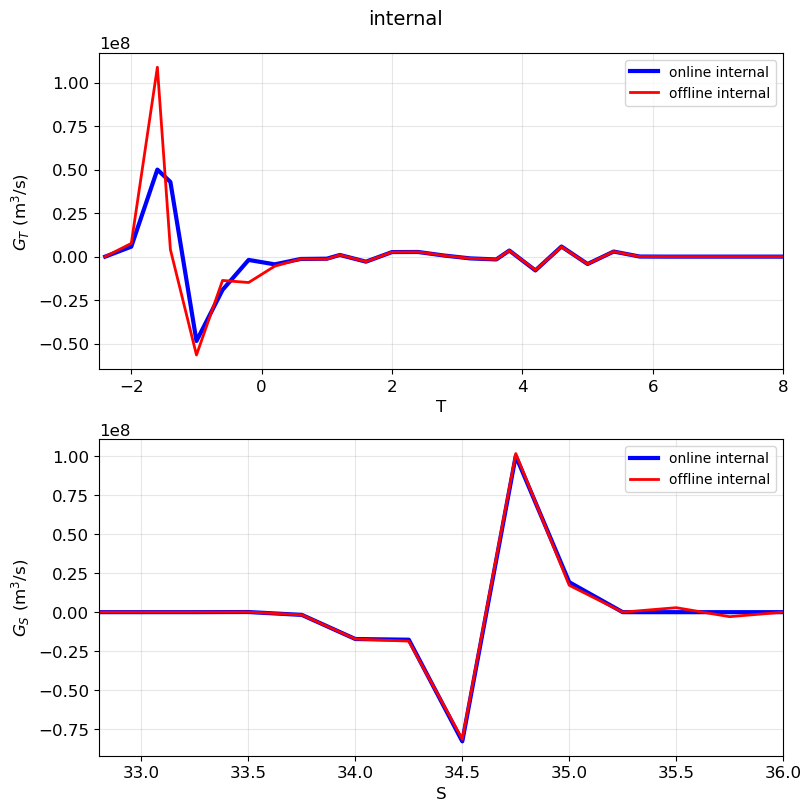

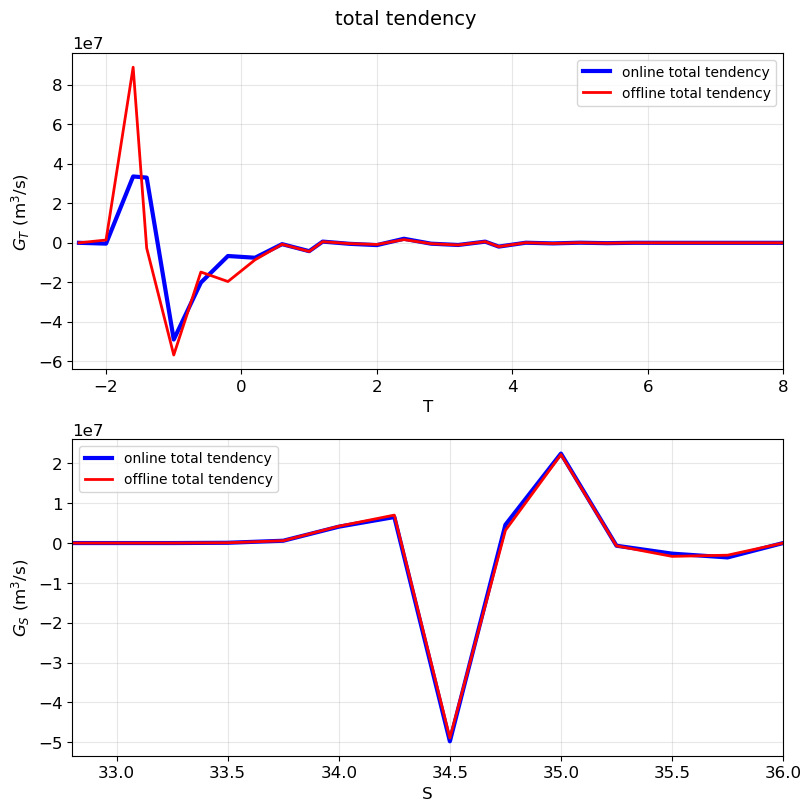

In [47]:
grouped_terms = {
    "advh": {
        "GT_on": advhGT_on,
        "GT_off": advhGT_off,
        "GS_on": advhGS_on,
        "GS_off": advhGS_off,
    },
    "surface": {
        "GT_on": surfGT_on,
        "GT_off": surfGT_off,
        "GS_on": surfGS_on,
        "GS_off": surfGS_off,
    },
    "internal": {
        "GT_on": internalGT_on,
        "GT_off": internalGT_off,
        "GS_on": internalGS_on,
        "GS_off": internalGS_off,
    },
    "total tendency": {
        "GT_on": tendGT_on,
        "GT_off": tendGT_off,
        "GS_on": tendGS_on,
        "GS_off": tendGS_off,
    },
}


def plot_grouped_G(term_name, boundsS, boundsT, grouped_terms,
                   xlimT=(-2.5, 8), xlimS=(32.8, 36)):
    term = grouped_terms[term_name]

    xT = boundsT.flatten()[1:-1]
    xS = boundsS.flatten()[1:-1]

    fig, axes = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

    # GT
    axes[0].plot(xT, term["GT_on"], c="blue", linewidth=3,
                 label=f"online {term_name}")
    axes[0].plot(xT, term["GT_off"], c="red", linewidth=2,
                 label=f"offline {term_name}")
    axes[0].set_ylabel(r"$G_T$ (m$^3$/s)")
    axes[0].set_xlabel("T")
    axes[0].set_xlim(*xlimT)
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.3)

    # GS
    axes[1].plot(xS, term["GS_on"], c="blue", linewidth=3,
                 label=f"online {term_name}")
    axes[1].plot(xS, term["GS_off"], c="red", linewidth=2,
                 label=f"offline {term_name}")
    axes[1].set_ylabel(r"$G_S$ (m$^3$/s)")
    axes[1].set_xlabel("S")
    axes[1].set_xlim(*xlimS)
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(term_name, fontsize=14)
    plt.show()


# plot all grouped terms
for name in ["advh", "surface", "internal", "total tendency"]:
    plot_grouped_G(name, boundsS, boundsT, grouped_terms)

In [48]:
# G_S[name][ts].keys()
name = 'BarentsS'
print(G_T['BarentsS'][ts].keys())

dict_keys(['tend', 'ADVr', 'ADVh', 'DFrT', 'DFhT', 'surf'])


In [49]:
# all residuals for T
residADVT = G_T[name][ts]['ADVh'] - dF_Tnew[0]/binwidthT1    # ADVh, m^3/s
residADVrT = G_T[name][ts]['ADVr'] - dF_Tnew[1]/binwidthT1   # ADVr, m^3/s
residDFhT = G_T[name][ts]['DFhT'] - dF_Tnew[2]/binwidthT1   # m^3/s
residDFrT = G_T[name][ts]['DFrT'] - dF_Tnew[3]/binwidthT1   # m^3/s
residsurfT = G_T[name][ts]['surf'] - dF_Tnew[4]/binwidthT1   # m^3/s
residKPPT = -dF_Tnew[5]/binwidthT1   # m^3/s

# all residuals for S
residADVS = G_S[name][ts]['ADVh'] - dF_Snew[0]/binwidthS1    # ADVh, m^3/s
residADVrS = G_S[name][ts]['ADVr'] - dF_Snew[1]/binwidthS1   # ADVr, m^3/s
residDFhS = G_S[name][ts]['DFhS'] - dF_Snew[2]/binwidthS1   # m^3/s
residDFrS = G_S[name][ts]['DFrS'] - dF_Snew[3]/binwidthS1   # m^3/s
residsurfS = G_S[name][ts]['surf'] - dF_Snew[4]/binwidthS1   # m^3/s
residKPPS = -dF_Snew[5]/binwidthS1   # m^3/s

# --- Total residual arrays for T ---
resid_advh_T      = residADVT
resid_internal_T  = residADVrT + residDFhT + residDFrT + residKPPT
resid_surface_T   = residsurfT

# --- Total residual arrays for S ---
resid_advh_S      = residADVS
resid_internal_S  = residADVrS + residDFhS + residDFrS + residKPPS
resid_surface_S   = residsurfS

# residual in each T bin across all T terms
resid_total_per_Tbin = (
    residADVT + residADVrT + residDFhT + residDFrT + residsurfT + residKPPT
)

# residual in each S bin across all S terms
resid_total_per_Sbin = (
    residADVS + residADVrS + residDFhS + residDFrS + residsurfS + residKPPS
)

In [50]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx) * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
SALT  = SALT.reshape(nz, ny, nx) * np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
SALT[SALT==0] = np.nan
THETA[THETA==0] = np.nan


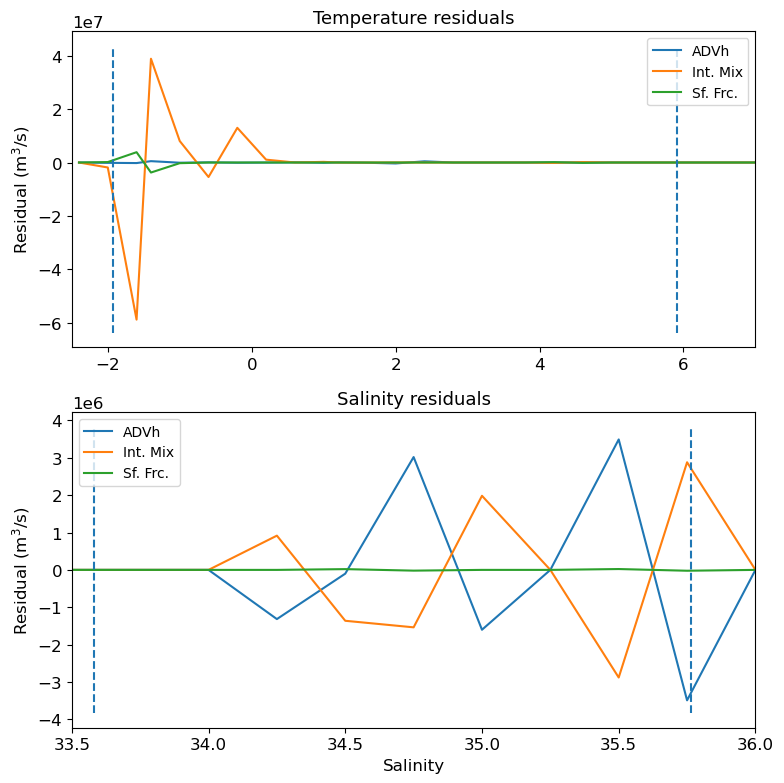

In [51]:
xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

fig = plt.figure(figsize=(8, 8))

# ---------- Temperature ----------
ax = plt.subplot(211)
ax.plot(xT, resid_advh_T, label='ADVh')
ax.plot(xT, resid_internal_T, label='Int. Mix')
ax.plot(xT, resid_surface_T, label='Sf. Frc.')


ax.set_xlim(-2.5, 7)
ax.set_ylabel('Residual (m$^3$/s)')
ax.set_title('Temperature residuals')
ax.legend(loc='best')

ymin, ymax = ax.get_ylim()
ax.vlines(
    [np.nanmin(THETA), np.nanmax(THETA)],
    ymin, ymax,
    linestyles='dashed'
)

# ---------- Salinity ----------
ax = plt.subplot(212)
ax.plot(xS, resid_advh_S, label='ADVh')
ax.plot(xS, resid_internal_S, label='Int. Mix')
ax.plot(xS, resid_surface_S, label='Sf. Frc.')

ax.set_xlim(33.5, 36)
ax.set_xlabel('Salinity')
ax.set_ylabel('Residual (m$^3$/s)')
ax.set_title('Salinity residuals')
ax.legend(loc='best')

ymin, ymax = ax.get_ylim()
ax.vlines(
    [np.nanmin(SALT), np.nanmax(SALT)],
    ymin, ymax,
    linestyles='dashed'
)

plt.tight_layout()
plt.savefig("Gonvsoff.png",dpi=300)
plt.show()

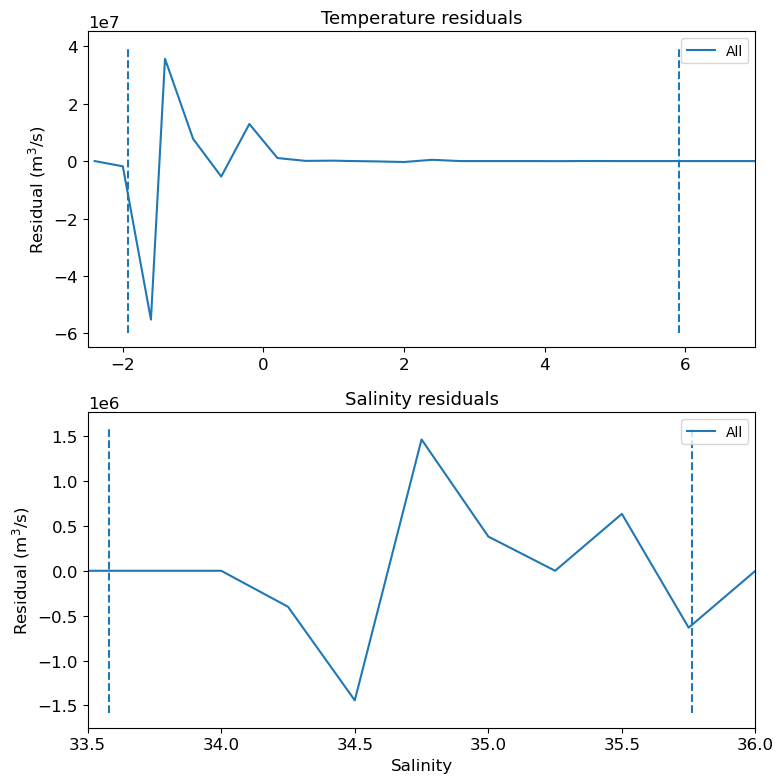

In [52]:
xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

fig = plt.figure(figsize=(8, 8))

# ---------- Temperature ----------
ax = plt.subplot(211)
ax.plot(xT, resid_advh_T + resid_internal_T + resid_surface_T, label='All')


ax.set_xlim(-2.5, 7)
ax.set_ylabel('Residual (m$^3$/s)')
ax.set_title('Temperature residuals')
ax.legend(loc='best')

ymin, ymax = ax.get_ylim()
ax.vlines(
    [np.nanmin(THETA), np.nanmax(THETA)],
    ymin, ymax,
    linestyles='dashed'
)

# ---------- Salinity ----------
ax = plt.subplot(212)
ax.plot(xS, resid_advh_S + resid_internal_S + resid_surface_S, label='All')

ax.set_xlim(33.5, 36)
ax.set_xlabel('Salinity')
ax.set_ylabel('Residual (m$^3$/s)')
ax.set_title('Salinity residuals')
ax.legend(loc='best')

ymin, ymax = ax.get_ylim()
ax.vlines(
    [np.nanmin(SALT), np.nanmax(SALT)],
    ymin, ymax,
    linestyles='dashed'
)

plt.tight_layout()
plt.show()

## MAPPING

We would need to be able to return to points from the previous analysis

In [53]:

MsumT,termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)
MsumS,termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)
# these have advh, advr, dfh, dfr, surf, kpp, tend and have not been normalized

In [54]:
# what we need to do to achieve an accurate comparison is to be able to normalize these by the bin width at the cell
# we would use THETA and SALT to bin termsT3D and termsS3D, and normalize by the index in binwidthT1 and binwidthS1

def _bincount_sum_with_nan(idx, vals, nout):
    """
    NaN-aware per-bin sum:
    if *all* entries in a bin are NaN, that bin returns NaN;
    otherwise NaNs are ignored and finite values are summed.
    """
    # track counts of non-nan contributions
    finite = np.isfinite(vals)
    sums   = np.bincount(idx[finite], vals[finite], minlength=nout).astype(float)
    counts = np.bincount(idx[finite], None, minlength=nout).astype(float)
    out = sums
    out[counts == 0] = np.nan
    return out
def normalize_and_bin_terms(
    terms3D, tracer3D, binmid, binwidth1
):
    tracer_flat = tracer3D.ravel(order="C")
    nbinm1 = len(binwidth1)

    bin_idx = np.digitize(tracer_flat, binmid, right=False) - 1
    valid = (bin_idx >= 0) & (bin_idx < nbinm1) & np.isfinite(tracer_flat)

    denom_flat = np.full(tracer_flat.shape, np.nan, dtype=float)
    denom_flat[valid] = binwidth1[bin_idx[valid]]

    bin_idx_out = np.full(tracer_flat.shape, -1, dtype=int)
    bin_idx_out[valid] = bin_idx[valid]
    bin_idx_3d = bin_idx_out.reshape(tracer3D.shape, order="C")

    terms_norm_3d = {}
    terms_binned_1d = {}

    for key, arr in terms3D.items():
        arr_flat = np.ravel(arr, order="C").astype(float)

        norm_flat = np.full(arr_flat.shape, np.nan, dtype=float)
        valid_term = valid & np.isfinite(arr_flat)
        norm_flat[valid_term] = arr_flat[valid_term] / denom_flat[valid_term]

        terms_norm_3d[key] = norm_flat.reshape(arr.shape, order="C")
        terms_binned_1d[key] = _bincount_sum_with_nan(
            bin_idx[valid_term],
            norm_flat[valid_term],
            nbinm1
        )

    return terms_norm_3d, terms_binned_1d, bin_idx_3d


# following in m^3/s
termsT3D_norm, termsT_binned, Tbin_idx_3d = normalize_and_bin_terms(
    termsT3D, THETA, binmidT, binwidthT1
)

termsS3D_norm, termsS_binned, Sbin_idx_3d = normalize_and_bin_terms(
    termsS3D, SALT, binmidS, binwidthS1
)

(140.0, 190.0)

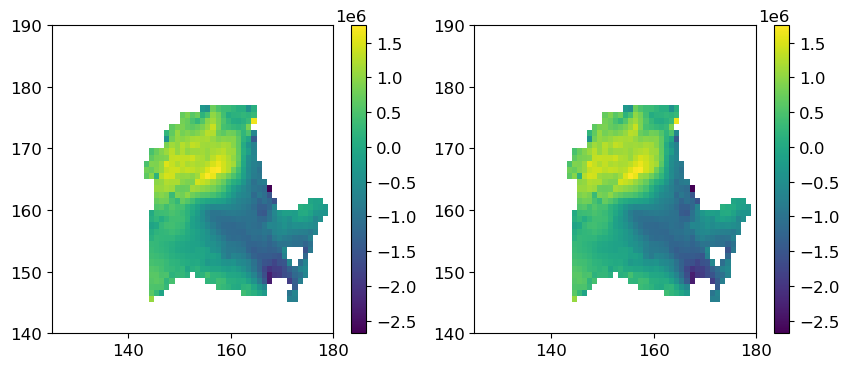

In [55]:
fig = plt.figure()

ax = plt.subplot(121)
cb = ax.pcolormesh(get_aste_tracer(G_S[name]['map'][ts]['ADVh'],nfx,nfy)[0])
plt.colorbar(cb)
ax.set_xlim(125,180)
ax.set_ylim(140,190)
ax = plt.subplot(122)
cb = ax.pcolormesh(get_aste_tracer(np.nansum(termsS3D_norm['ADVh'],axis=0)*mymsk,nfx,nfy)[0])           # PSU.m^3/s
# cb = ax.pcolormesh(get_aste_tracer(termsT3D['ADVh'][0]*mymsk,nfx,nfy)[0])
plt.colorbar(cb)
ax.set_xlim(125,180)
ax.set_ylim(140,190)

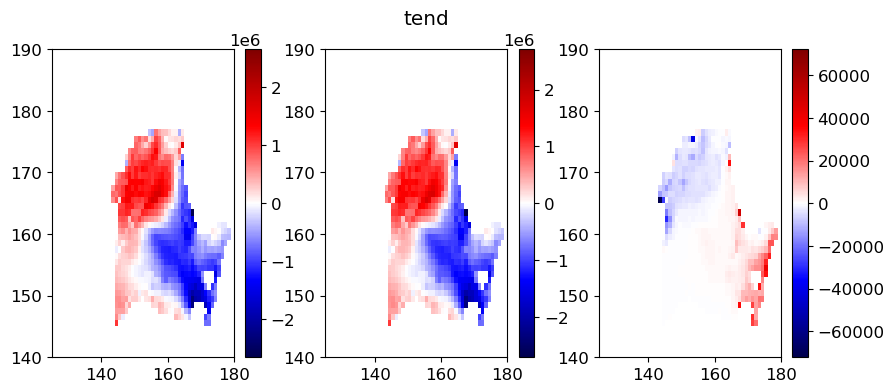

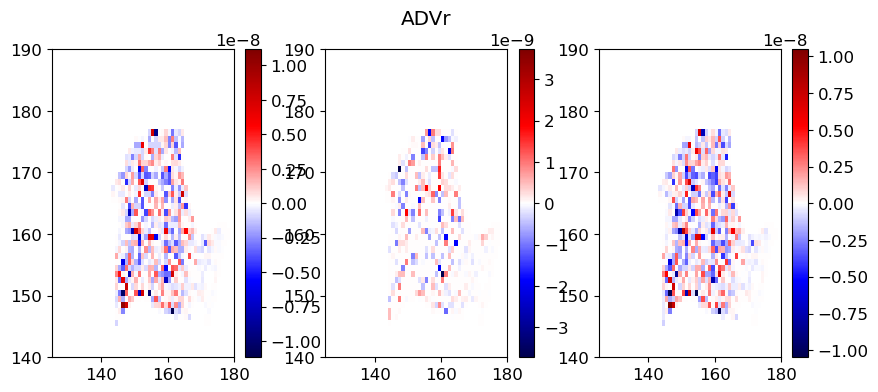

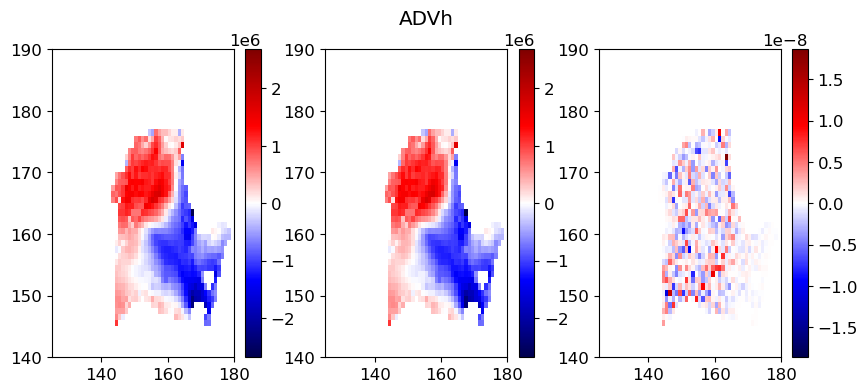

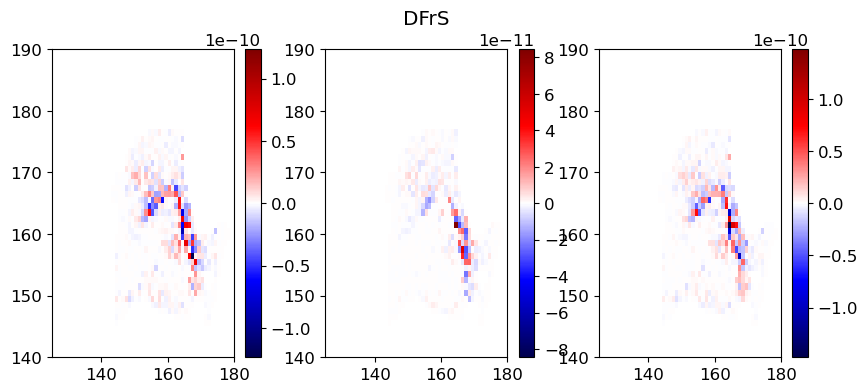

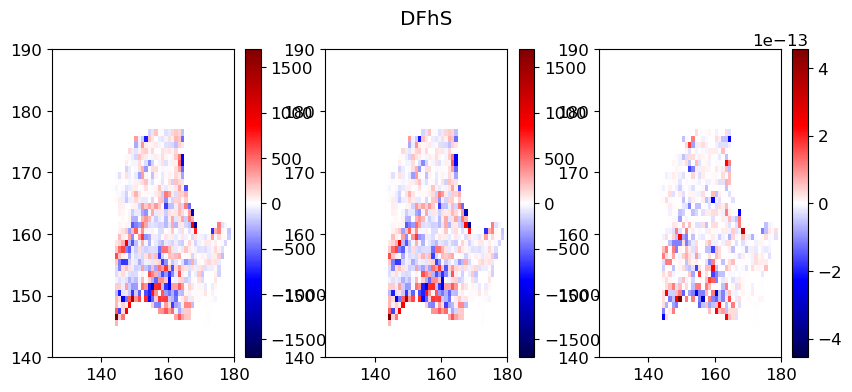

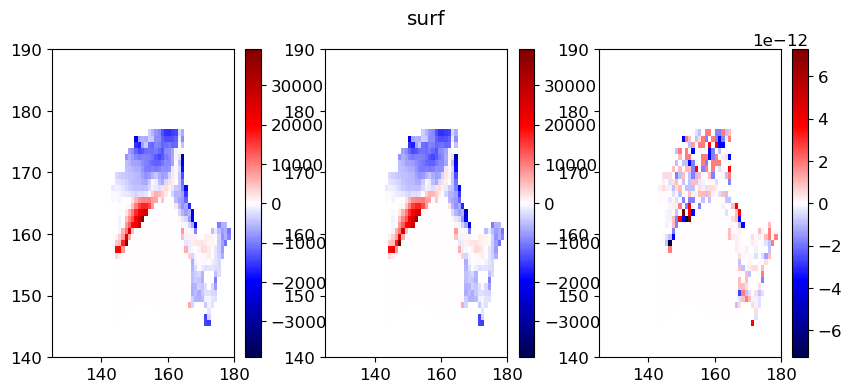

In [56]:
# loop through and see resid for these

for key in list(G_S[name]['map'][ts].keys()):
    fig = plt.figure()

    ax = plt.subplot(131)
    a = get_aste_tracer(G_S[name]['map'][ts][key],nfx,nfy)[0]
    vlev = np.nanmax(np.abs(a))
    cb = ax.pcolormesh(a,cmap='seismic',vmin=-vlev,vmax=vlev)
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)
    ax = plt.subplot(132)
    b = get_aste_tracer(np.nansum(termsS3D_norm[key],axis=0)*mymsk,nfx,nfy)[0]
    vlev = np.nanmax(np.abs(b))
    cb = ax.pcolormesh(b,cmap='seismic',vmin=-vlev,vmax=vlev)           # PSU.m^3/s
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)
    ax = plt.subplot(133)
    c = a-b
    vlev = np.nanmax(np.abs(c))
    cb = ax.pcolormesh(c,cmap='seismic',vmin=-vlev,vmax=vlev)           # PSU.m^3/s
    # cb = ax.pcolormesh(get_aste_tracer(termsT3D['ADVh'][0]*mymsk,nfx,nfy)[0])
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)

    plt.suptitle(key)

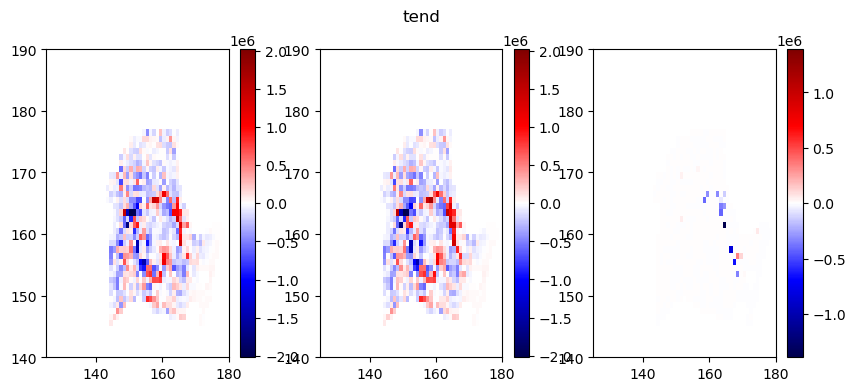

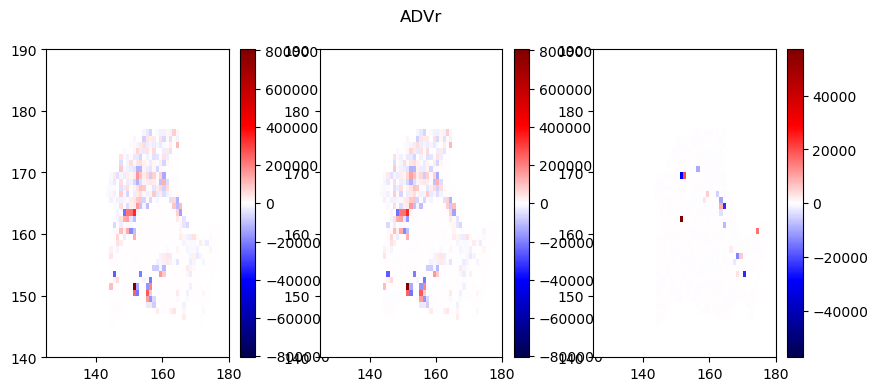

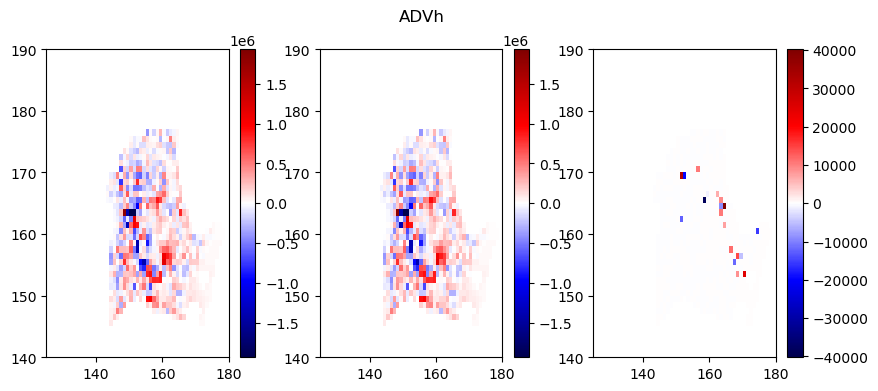

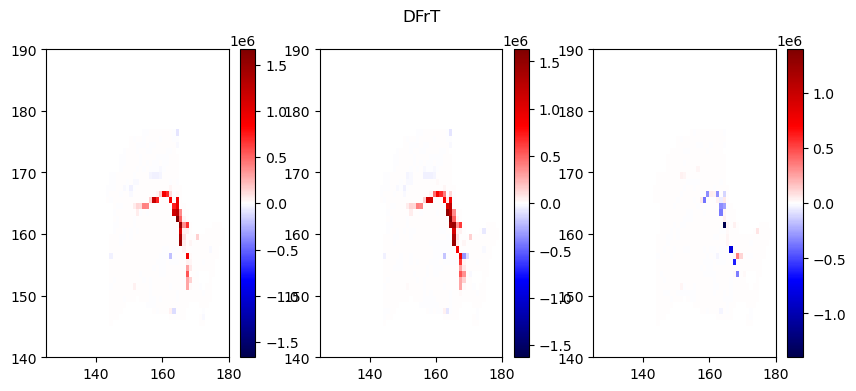

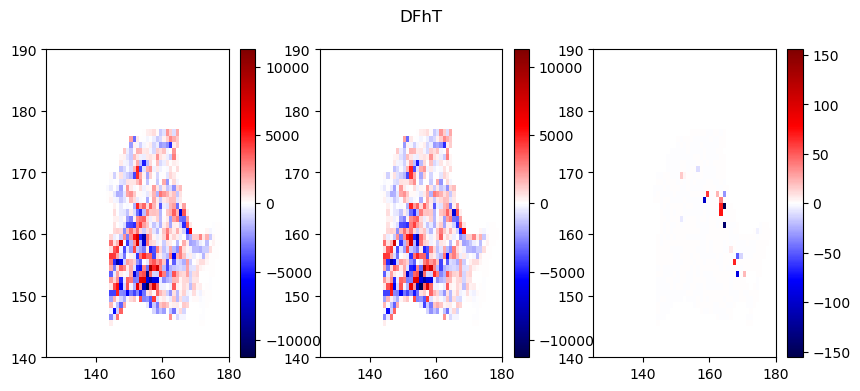

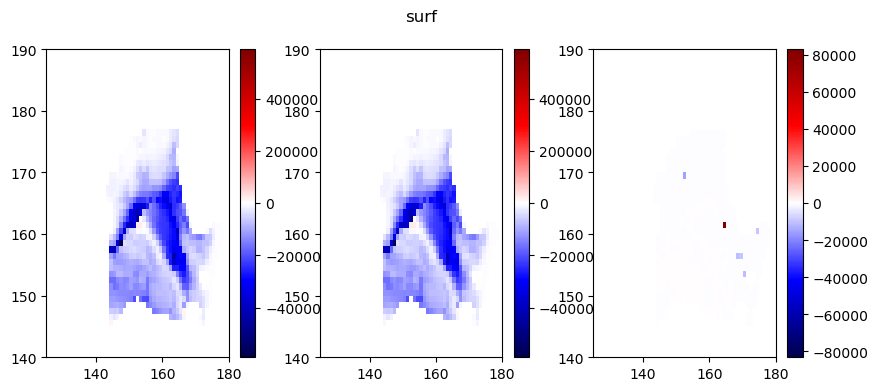

In [37]:
# loop through and see resid for these

for key in list(G_T[name]['map'][ts].keys()):
    fig = plt.figure()

    ax = plt.subplot(131)
    a = get_aste_tracer(G_T[name]['map'][ts][key],nfx,nfy)[0]
    vlev = np.nanmax(np.abs(a))
    cb = ax.pcolormesh(a,cmap='seismic',vmin=-vlev,vmax=vlev)
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)
    ax = plt.subplot(132)
    b = get_aste_tracer(np.nansum(termsT3D_norm[key],axis=0)*mymsk,nfx,nfy)[0]
    vlev = np.nanmax(np.abs(b))
    cb = ax.pcolormesh(b,cmap='seismic',vmin=-vlev,vmax=vlev)           # m^3/s
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)
    ax = plt.subplot(133)
    c = a-b
    vlev = np.nanmax(np.abs(c))
    cb = ax.pcolormesh(c,cmap='seismic',vmin=-vlev,vmax=vlev)           # m^3/s
    plt.colorbar(cb)
    ax.set_xlim(125,180)
    ax.set_ylim(140,190)

    plt.suptitle(key)

### fix these two figures and add these to meeting notes and discussion

In [38]:
# add the SI tracer to this

from scipy.ndimage import binary_dilation

def jfm_mean_SI_masked(
    tsstr, *,  # expects month timesteps; for JFM mean use Jan..Apr so you can form Jan,Feb,Mar month-means
    dirState, ny, nx, nfx, nfy,
    landmsk, mymsk,
    file_name="state_2d_set1",
    varname="SIarea",
    land_buffer_iters=1,
):
    """
    Returns:
      SI_masked_mean_tr : (tile) 2D on tracer grid (get_aste_tracer(...)[0]) AFTER land-buffer masking,
                          averaged over JFM monthly means.
      SI_mean_tr        : same but without land-buffer masking
      meta              : dict with used pairs and timesteps

    Convention:
      Each monthly mean uses the *second* timestep in the pair (matches your read=[int(tsstr[1])] pattern).
      JFM mean is the average of the 3 monthly fields from pairs:
        Jan=[ts0,ts1], Feb=[ts1,ts2], Mar=[ts2,ts3]
      So you should pass tsstr = [Jan, Feb, Mar, Apr] (length 4).
    """
    tsstr = list(tsstr)
    if len(tsstr) < 2:
        raise ValueError("Need at least 2 timesteps to form one monthly field.")
    npairs = len(tsstr) - 1
    if npairs < 1:
        raise ValueError("Need at least one pair.")

    # --- parse meta once to find record index ---
    meta_state_2d = parsemeta(os.path.join(dirState, f"{file_name}.{tsstr[0]}.meta"))
    fldlist = np.array(meta_state_2d["fldList"])
    idx = np.where(fldlist == varname)[0]
    if len(idx) == 0:
        raise KeyError(f"{varname} not in fldList. Available: {list(fldlist)}")
    rec = int(idx[0])

    # --- land buffer mask on tracer grid (constant across time) ---
    landmask_tr = (get_aste_tracer(landmsk, nfx, nfy)[0] > 0)
    landbuffer_tr = binary_dilation(landmask_tr, iterations=land_buffer_iters)

    # --- loop month-pairs and accumulate on tracer grid ---
    acc_tr = None
    acc_masked_tr = None

    pairs = []
    for i in range(npairs):
        pairs.append((tsstr[i], tsstr[i + 1]))

        # match your convention: use the second timestep of the pair
        read = [int(tsstr[i + 1])]
        SIarea_frac, its, meta = rdmds(
            os.path.join(dirState, file_name),
            read,
            returnmeta=True,
            rec=rec
        )  # m^2/m^2
        SIarea = np.asarray(SIarea_frac).reshape((ny, nx))

        # map to tracer-tile (your plotting face)
        SI_tr = get_aste_tracer(SIarea, nfx, nfy)[0]

        # apply land-buffer mask
        SI_masked = np.where(landbuffer_tr, np.nan, SI_tr)

        if acc_tr is None:
            acc_tr = np.zeros_like(SI_tr, dtype=np.float64)
            acc_masked_tr = np.zeros_like(SI_tr, dtype=np.float64)
            cnt_tr = np.zeros_like(SI_tr, dtype=np.float64)
            cnt_masked = np.zeros_like(SI_tr, dtype=np.float64)

        # nan-safe accumulate (mean over time)
        ok = np.isfinite(SI_tr)
        acc_tr[ok] += SI_tr[ok]
        cnt_tr[ok] += 1.0

        okm = np.isfinite(SI_masked)
        acc_masked_tr[okm] += SI_masked[okm]
        cnt_masked[okm] += 1.0

    SI_mean_tr = acc_tr / np.where(cnt_tr > 0, cnt_tr, np.nan)
    SI_masked_mean_tr = acc_masked_tr / np.where(cnt_masked > 0, cnt_masked, np.nan)

    meta_out = {"ts_list": tsstr, "pairs": pairs, "npairs": npairs, "read_second_of_pair": True}
    return SI_masked_mean_tr, SI_mean_tr, meta_out


# -------------------------
# Example: JFM mean SI for 2007
# (need Jan..Apr timesteps so you can form 3 monthly fields)
# -------------------------

SI_masked, SI_JFM, metaSI = jfm_mean_SI_masked(
    tsstr,
    dirState=dirstate, ny=ny, nx=nx, nfx=nfx, nfy=nfy,
    landmsk=landmsk, mymsk=mymsk,  # mymsk not used here except you might want it later
    land_buffer_iters=1,
)

In [39]:
# SI_masked.shape

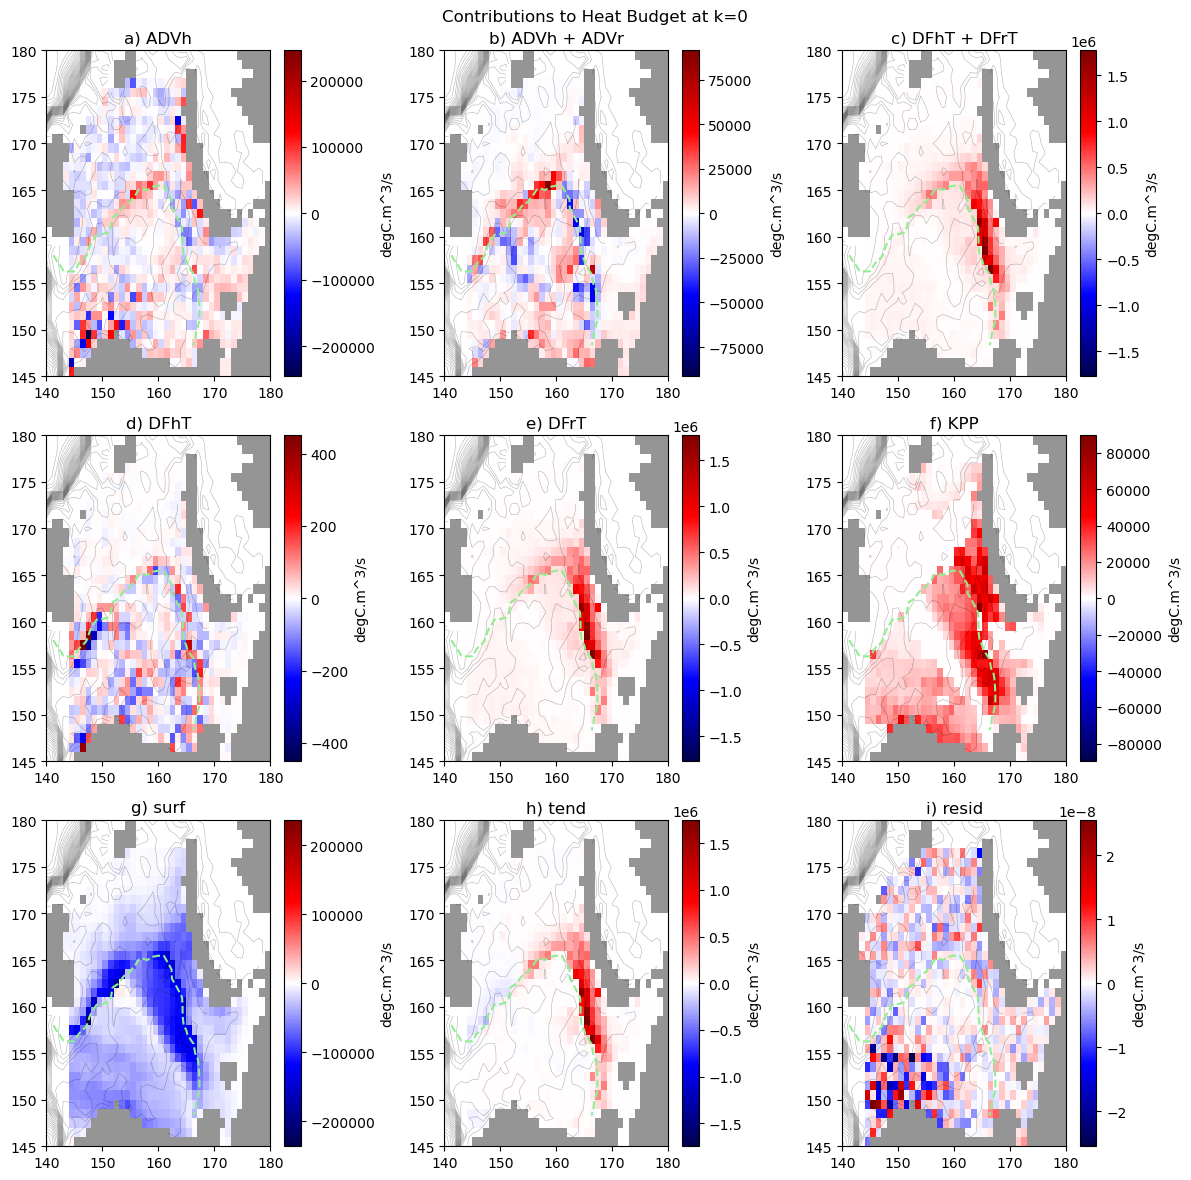

In [40]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

klev = 0

# --- precompute static fields once ---
land_plot = landmsk.copy().astype(float)
land_plot[land_plot == 0] = np.nan
land_plot_aste = get_aste_tracer(land_plot, nfx, nfy)[0]

depth_plot = mygrid['Depth'].copy().astype(float)
depth_plot[depth_plot <= 0] = np.nan   # mask land if Depth is 0 or negative there
depth_aste = get_aste_tracer(depth_plot, nfx, nfy)[0]

depth_levels = np.arange(100, np.nanmax(depth_plot) + 100, 100)

# --- define all panels once ---
plot_defs = [
    ("a) ADVh",                 termsT3D['ADVh'][klev] * mymsk),
    ("b) ADVh + ADVr",         (termsT3D['ADVh'][klev] + termsT3D['ADVr'][klev]) * mymsk),
    ("c) DFhT + DFrT",         (termsT3D['DFhT'][klev] + termsT3D['DFrT'][klev]) * mymsk),
    ("d) DFhT",                 termsT3D['DFhT'][klev] * mymsk),
    ("e) DFrT",                 termsT3D['DFrT'][klev] * mymsk),
    ("f) KPP",                  termsT3D['KPP'][klev] * mymsk),
    ("g) surf",                 termsT3D['surf'][klev] * mymsk),
    ("h) tend",                 termsT3D['tend'][klev] * mymsk),
]

resid = (
    termsT3D['tend'][klev]
    - termsT3D['ADVh'][klev]
    - termsT3D['ADVr'][klev]
    - termsT3D['DFhT'][klev]
    - termsT3D['DFrT'][klev]
    - termsT3D['KPP'][klev]
    - termsT3D['surf'][klev]
) * mymsk

plot_defs.append(("i) resid", resid))

# --- plot loop ---
for ax, (title, field) in zip(axes.flat, plot_defs):
    b = get_aste_tracer(field, nfx, nfy)[0]
    vlev = np.nanmax(np.abs(b))

    cb = ax.pcolormesh(b, cmap='seismic', vmin=-vlev, vmax=vlev)

    # land on every plot
    ax.pcolormesh(land_plot_aste, cmap='Greys', vmin=-2, vmax=4)

    # bathymetry contours every 100 m
    ax.contour(depth_aste, levels=depth_levels, colors='k', linewidths=0.4, alpha=0.3)
    ax.contour(SI_masked,levels=[0.15],colors="lightgreen",linewidths=1.5,linestyles="--",zorder=10)

    plt.colorbar(cb, ax=ax, label="degC.m^3/s")
    ax.set_xlim(140, 180)
    ax.set_ylim(145, 180)
    ax.set_title(title)

plt.suptitle("Contributions to Heat Budget at k=" + str(klev))
plt.tight_layout()
plt.savefig("heatbudg_map_miniaste_k0.png",dpi=300)

In [41]:
np.cumsum(mygrid['DRF'])[15]

182.30999999999997

# Look at the overall WMT

In [42]:
# quickly validate the internal gates
print(MsumT['Msum'].sum()-dF_Tnew[0].sum())
print(MsumS['Msum'].sum()-dF_Snew[0].sum())

0.0
-9.313225746154785e-10


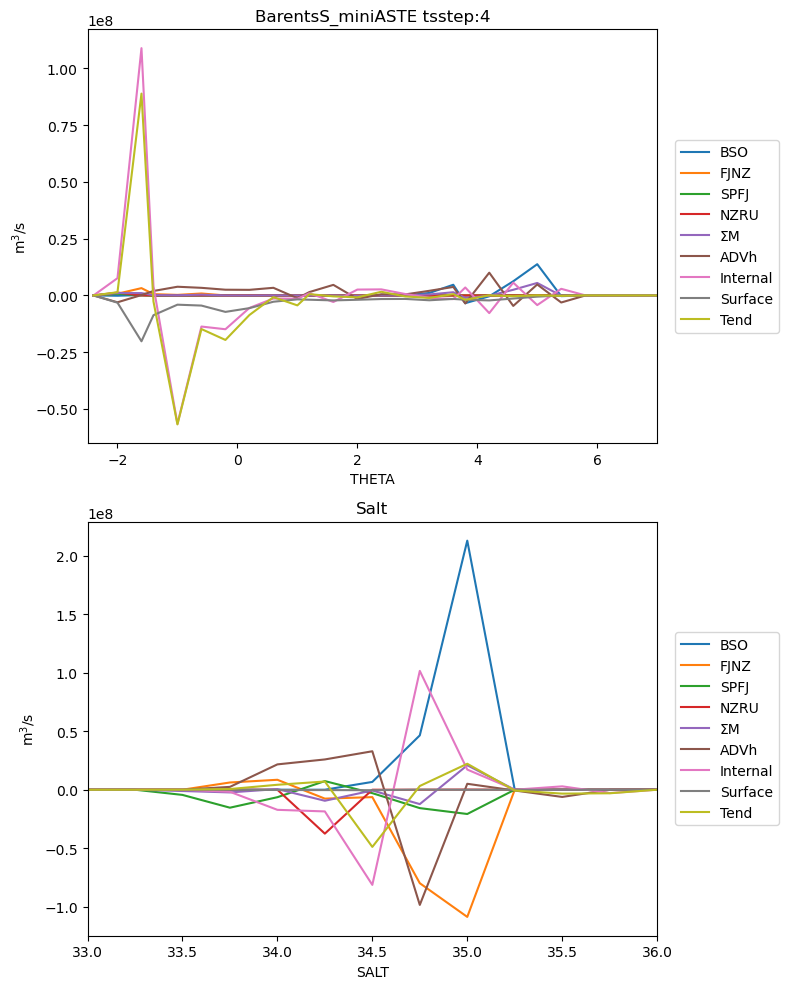

In [43]:
fig = plt.figure(figsize=(8, 10))

xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

# Temperature
ax1 = plt.subplot(211)

for key in list(MsumT.keys())[:4]:
    ax1.plot(xT, MsumT[key] / binwidthT1, label=key)

ax1.plot(xT, MsumT['Msum'], label="ΣM")
ax1.plot(xT, advhGT_off, label="ADVh")
ax1.plot(xT, internalGT_off, label="Internal")
ax1.plot(xT, surfGT_off, label="Surface")
ax1.plot(xT, tendGT_off, label="Tend")

ax1.set_xlim(-2.5, 7)
ax1.set_ylabel("m$^3$/s")
ax1.set_title("BarentsS_miniASTE tsstep:" + str(t2))
ax1.set_xlabel("THETA")

# move legend to the far right
ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))


# Salinity
ax2 = plt.subplot(212)

for key in list(MsumS.keys())[:4]:
    ax2.plot(xS, MsumS[key] / binwidthS1, label=key)

ax2.plot(xS, MsumS['Msum'], label="ΣM")
ax2.plot(xS, advhGS_off, label="ADVh")
ax2.plot(xS, internalGS_off, label="Internal")
ax2.plot(xS, surfGS_off, label="Surface")
ax2.plot(xS, tendGS_off, label="Tend")
ax2.set_xlim(33,36)

ax2.set_ylabel("m$^3$/s")
ax2.set_xlabel("SALT")
ax2.set_title("Salt")
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()

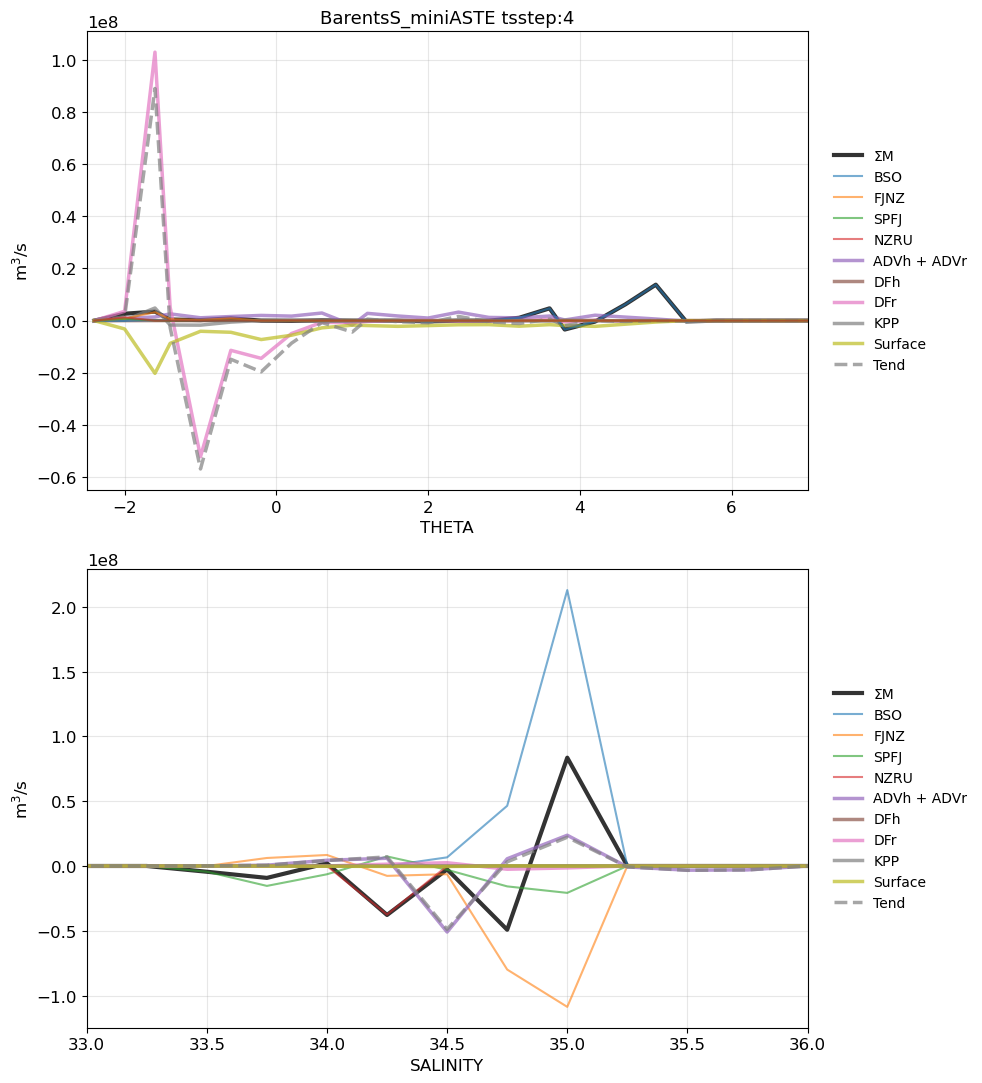

In [59]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 11))

xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

# Optional: cleaner default styling
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})

# -------------------------
# Temperature
# -------------------------
ax1 = plt.subplot(211)

# lighter, secondary lines
ax1.plot(xT, MsumT['Msum']/binwidthT1,      lw=3.0, color='k', label="ΣM",alpha=0.8)

for key in list(MsumT.keys())[:4]:
    ax1.plot(
        xT, MsumT[key] / binwidthT1,
        lw=1.5, alpha=0.6, linestyle='-',
        label=key,zorder=4
    )

# main lines emphasized
ax1.plot(xT, advhGT_off + advrGT_off, lw=2.5, label="ADVh + ADVr",alpha=0.7)
ax1.plot(xT, dfhGT_off, lw=2.5, label="DFh",alpha=0.7)
ax1.plot(xT, dfrGT_off, lw=2.5, label="DFr",alpha=0.7)
ax1.plot(xT, kppGT_off,     lw=2.5, label="KPP",alpha=0.7)
ax1.plot(xT, surfGT_off,         lw=2.5, label="Surface",alpha=0.7)
ax1.plot(xT, tendGT_off,         lw=2.5, linestyle='--', color='gray', label="Tend",alpha=0.7)

ax1.set_xlim(-2.5, 7)
ax1.set_ylabel("m$^3$/s")
ax1.set_title("BarentsS_miniASTE tsstep:" + str(t2))
ax1.set_xlabel("THETA")
ax1.grid(alpha=0.3)

ax1.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# -------------------------
# Salinity
# -------------------------
ax2 = plt.subplot(212)

ax2.plot(xS, MsumS['Msum']/binwidthS1,      lw=3.0, color='k', label="ΣM",alpha=0.8)

for key in list(MsumS.keys())[:4]:
    ax2.plot(
        xS, MsumS[key] / binwidthS1,
        lw=1.5, alpha=0.6, linestyle='-',
        label=key
    )

ax2.plot(xS, advhGS_off + advrGS_off, lw=2.5, label="ADVh + ADVr",alpha=0.7)
ax2.plot(xS, dfhGS_off, lw=2.5, label="DFh",alpha=0.7)
ax2.plot(xS, dfrGS_off, lw=2.5, label="DFr",alpha=0.7)
ax2.plot(xS, kppGS_off,     lw=2.5, label="KPP",alpha=0.7)
ax2.plot(xS, surfGS_off,         lw=2.5, label="Surface",alpha=0.7)
ax2.plot(xS, tendGS_off,         lw=2.5, linestyle='--', color='gray', label="Tend",alpha=0.7)

ax2.set_xlim(33, 36)
ax2.set_ylabel("m$^3$/s")
ax2.set_xlabel("SALINITY")
# ax2.set_title("Salt")
ax2.grid(alpha=0.3)

ax2.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig("figs/sample_volbudg.png",dpi=300)

In [94]:
# print the sum of these in m^3/s so that I can compare in the document

print(np.nansum(advhGS_off),np.nansum(MsumS['Msum']/binwidthS1))
print(np.nansum(advhGT_off),np.nansum(MsumT['Msum']/binwidthT1))


-17571558.60021411 -17571558.600214113
28472946.473357048 29114834.89735604


## Load the J terms and plot on top of the volume distribution

In [95]:
# volume should be binned to 
####################################################################################################
print("doing volume")
# get the total volume
# for mass tendency (m^3/s) - time is not yet included in this block
file_name = 'budg2d_snap_set1'
DRF3d = np.tile(mygrid['DRF'][:,np.newaxis,np.newaxis],(1,ny,nx))

# assuming all files are structured the same
meta_budg2d_snap_set1 = parsemeta(dirbudg + file_name + "." + tsstr[0]+ ".meta")
# try to read this with rec
fldlist = np.array(meta_budg2d_snap_set1['fldList'])
varnames = np.array(['ETAN'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

# set for all months
vol = np.zeros((len(tsstr),nz, ny, nx))
#print("volume allocation shape",vol.shape)

for t in range(len(tsstr)):
    tmpvol = np.tile(mygrid['DXG'][np.newaxis,:,:],(50,1,1)) * np.tile(mygrid['DYG'][np.newaxis,:,:],(50,1,1)) * DRF3d

    vol[t,:,:,:] = tmpvol * np.tile(mymsk, (nz, 1, 1))
#######
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

THETA = THETA.reshape(nz,ny,nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
SALT = SALT.reshape(nz,ny,nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

# bin this to T_center and S_center
T_centers.shape
S_centers.shape

doing volume


(112,)

In [96]:


# create the binned values for theta and salt
binned_theta = bin_array(THETA, T_centers).astype(float)
binned_salinity = bin_array(SALT, S_centers).astype(float)

# anything assigned to the overflow bin becomes NaN
binned_theta[binned_theta == nT] = np.nan
binned_salinity[binned_salinity == nS] = np.nan

maskArc = mymsk
idxs = np.where(maskArc == 1)

# number of actual bins = edges - 1
nT_bins = nT - 1
nS_bins = nS - 1

# if dT and dS are scalars:
vol_mesh = create_TS_mesh(
    binned_theta,
    binned_salinity,
    vol[0],      # or the correct time slice matching THETA/SALT
    idxs,
    nT_bins,
    nS_bins,
    dT_centers,
    dS_centers
)

In [97]:
vol_mesh[vol_mesh==0] = np.nan

(-2.0, 10.0)

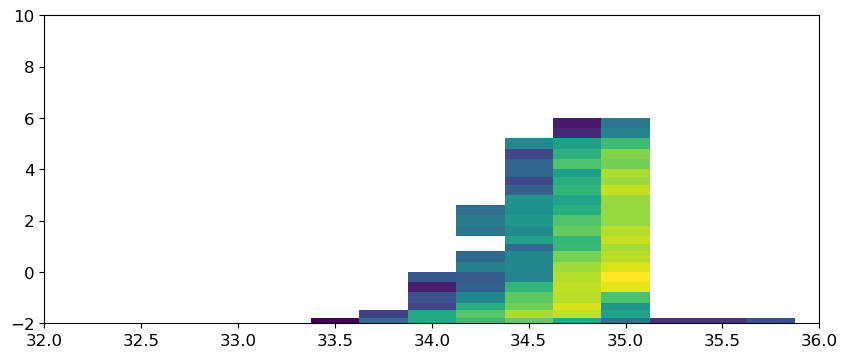

In [98]:
plt.pcolormesh(Sbin2,Tbin2,np.log10(vol_mesh.T),cmap='viridis')
plt.xlim(32,36)
plt.ylim(-2,10)

In [99]:
# Load the J terms for this (can be offline but should be online as well)

# we can load these but please make sure they're from the correct 

# create the same Jy offline as done before


dt = 1800
MsumT,termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
MsumS,termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
# all in m^3/s/tracer

In [100]:

termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

In [101]:
from create_aste90_layers import get_div

In [102]:
Jy_tend = termsT_TS['tend']   # m^3/s/PSU
Jx_tend = termsS_TS['tend']   # m^3/s/degC
Jy_tend *= 1e-6
Jx_tend *= 1e-6

(-2.0, 10.0)

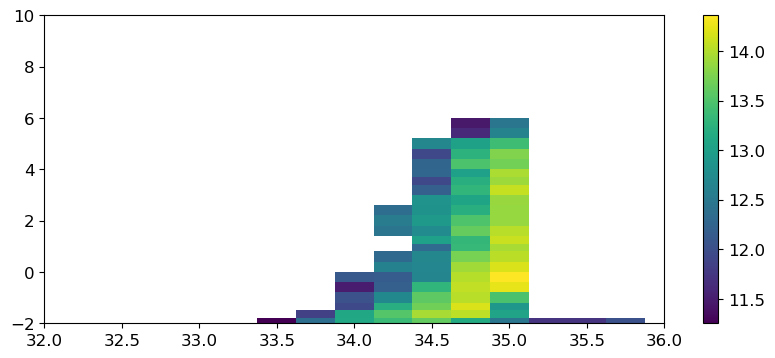

In [103]:
# plot the overall tendency vectors on the volume distribution

fig = plt.figure()

ax = plt.subplot(111)
cb = ax.pcolormesh(Sbin2,Tbin2,np.log10(vol_mesh.T),cmap='viridis')
plt.colorbar(cb)
ax.set_xlim(32,36)
ax.set_ylim(-2,10)

In [104]:
# add the isopycnals
# add the density contours from gsw
smin = 25.5 - (0.01 * 25.5)    #salt_ctrl_subregR.min - (0.01 * salt_ctrl_subregR.min)
smax = 38 + (0.01 * 38)    #salt_ctrl_subregR.max + (0.01 * salt_ctrl_subregR.max)
tmin = -2 + (0.1 * -2)       #temp_ctrl_subregR.min - (0.1 * temp_ctrl_subregR.max)
tmax = 31 + (0.1 * 31)       #temp_ctrl_subregR.max + (0.1 * temp_ctrl_subregR.max)
print('tmin, tmax, smin, smax sizes=,', tmin, tmax, smin, smax)
# Calculate how many gridcells we need in the x and y dimensions
xdim = 50
ydim = 50
# Create empty grid of zeros
dens = np.zeros((ydim,xdim))
# Create temp and salt vectors of appropiate dimensions
ti = np.linspace(-2,31,ydim)
si = np.linspace(25.5,38,xdim)
Freez_temp = gsw.CT_freezing(si,0,0)

Si, Ti = np.meshgrid(si, ti, sparse=False, indexing='ij')
# Loop to fill in grid with densities
for j in range(0,int(ydim)):
    for i in range(0, int(xdim)):
        #print(si[i],ti[j])
        dens[j,i]=gsw.rho(si[i],ti[j],0)
        # Substract 1000 to convert to sigma-0
dens2 = dens - 1000

tmin, tmax, smin, smax sizes=, -2.2 34.1 25.245 38.38


In [105]:
# tsstr

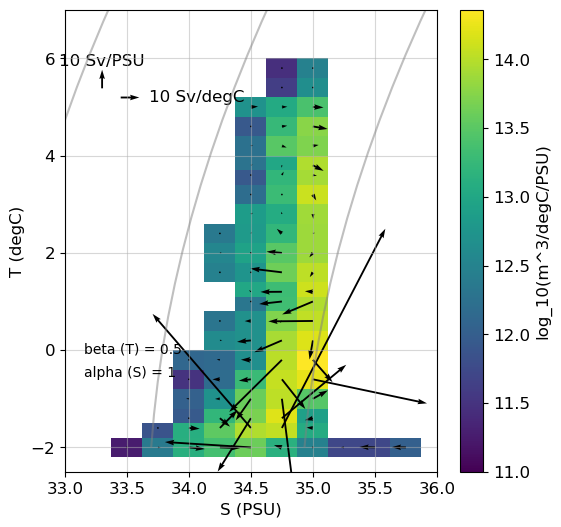

In [106]:
# plot these on a figure to show the budgeted terms
alpha = 1
beta = .5
arrow_length = 10     # for the sverdrup arrows
step=2
t = 0
U = arrow_length
scale = 2e2

xlims = np.array([33,36])
ylims = np.array([-2.5,7])


# first get the values and do conversions to Sv/degC or Sv/PSU
fig = plt.figure(figsize = (6,6))

# total tendency
ax = plt.subplot(111)
cb1 = ax.pcolormesh(Sbin2, Tbin2, np.log10(vol_mesh.T), cmap='viridis', vmin=11)
# Set U1 and V1 and apply alpha and beta scaling

U1, V1 = Jx_tend.T, Jy_tend.T
U1[U1 == 0], V1[V1 == 0] = np.nan, np.nan
U1, V1 = U1 * alpha, V1 * beta
# Plot quiver
q1 = ax.quiver(Sbin2,Tbin2, U1, V1, width=0.005, scale=scale)
plt.colorbar(cb1, label="log_10(m^3/degC/PSU)")
# Set title, limits, and grid
# ax.set_title("total tend " + datetimes[0].strftime("%Y-%m-%d"))
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_xlabel("S (PSU)")
ax.set_ylabel("T (degC)")
ax.grid(alpha=0.5)
# Add the quiver key for Sv/PSU
# Adjust X and Y to position the quiver key appropriately on the plot
quiver_length = 1.0  # Set the length of the arrow for the key
ax.quiverkey(q1,X=0.2,Y=0.81,U = U,label=str(U) + " Sv/degC",labelpos='E')
ax.quiverkey(q1, X=0.1, Y=0.85, U=U, label=str(U) + " Sv/PSU",angle=90, labelpos='N', coordinates='axes')

# Add alpha and beta text to the plot
ax.text(0.05, 0.2, f'alpha (S) = {alpha}', transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom')
ax.text(0.05, 0.25, f'beta (T) = {beta}', transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom')
# Add density contours
cs = ax.contour(si, ti, dens2, colors="grey", zorder=2, alpha=0.5, levels=np.arange(16, 32, 1))
cl = ax.clabel(cs, fontsize=10, inline=False, fmt="%.f")

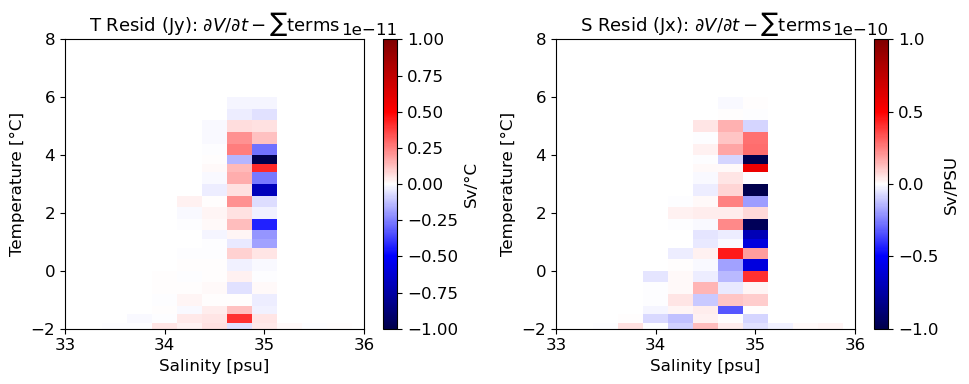

In [74]:
# quickly check the closure of the Jy and Jx terms

fig = plt.figure(figsize=(10, 4))

# --- Temperature (Jy) ---
ax = plt.subplot(121)

LHS = termsT_TS['tend']
RHS = (
    termsT_TS['ADVh'] + termsT_TS['ADVr'] +
    termsT_TS['DFhT'] + termsT_TS['DFrT'] +
    termsT_TS['surf'] + termsT_TS['KPP']
)
RHS *= 1e-6

cb = ax.pcolormesh(
    Sbin2, Tbin2, (LHS - RHS).T,
    cmap='seismic', vmin=-1e-11, vmax=1e-11
)
plt.colorbar(cb, ax=ax, label='Sv/°C')

ax.set_title(r'T Resid (Jy): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)

# --- Salinity (Jx) ---
ax = plt.subplot(122)

LHS = termsS_TS['tend']
RHS = (
    termsS_TS['ADVh'] + termsS_TS['ADVr'] +
    termsS_TS['DFhS'] + termsS_TS['DFrS'] +
    termsS_TS['surf'] + termsS_TS['KPP']
)
RHS *= 1e-6

cb = ax.pcolormesh(
    Sbin2, Tbin2, (LHS - RHS).T,
    cmap='seismic', vmin=-1e-10, vmax=1e-10
)
plt.colorbar(cb, ax=ax, label='Sv/PSU')

ax.set_title(r'S Resid (Jx): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)

plt.tight_layout()
plt.show()

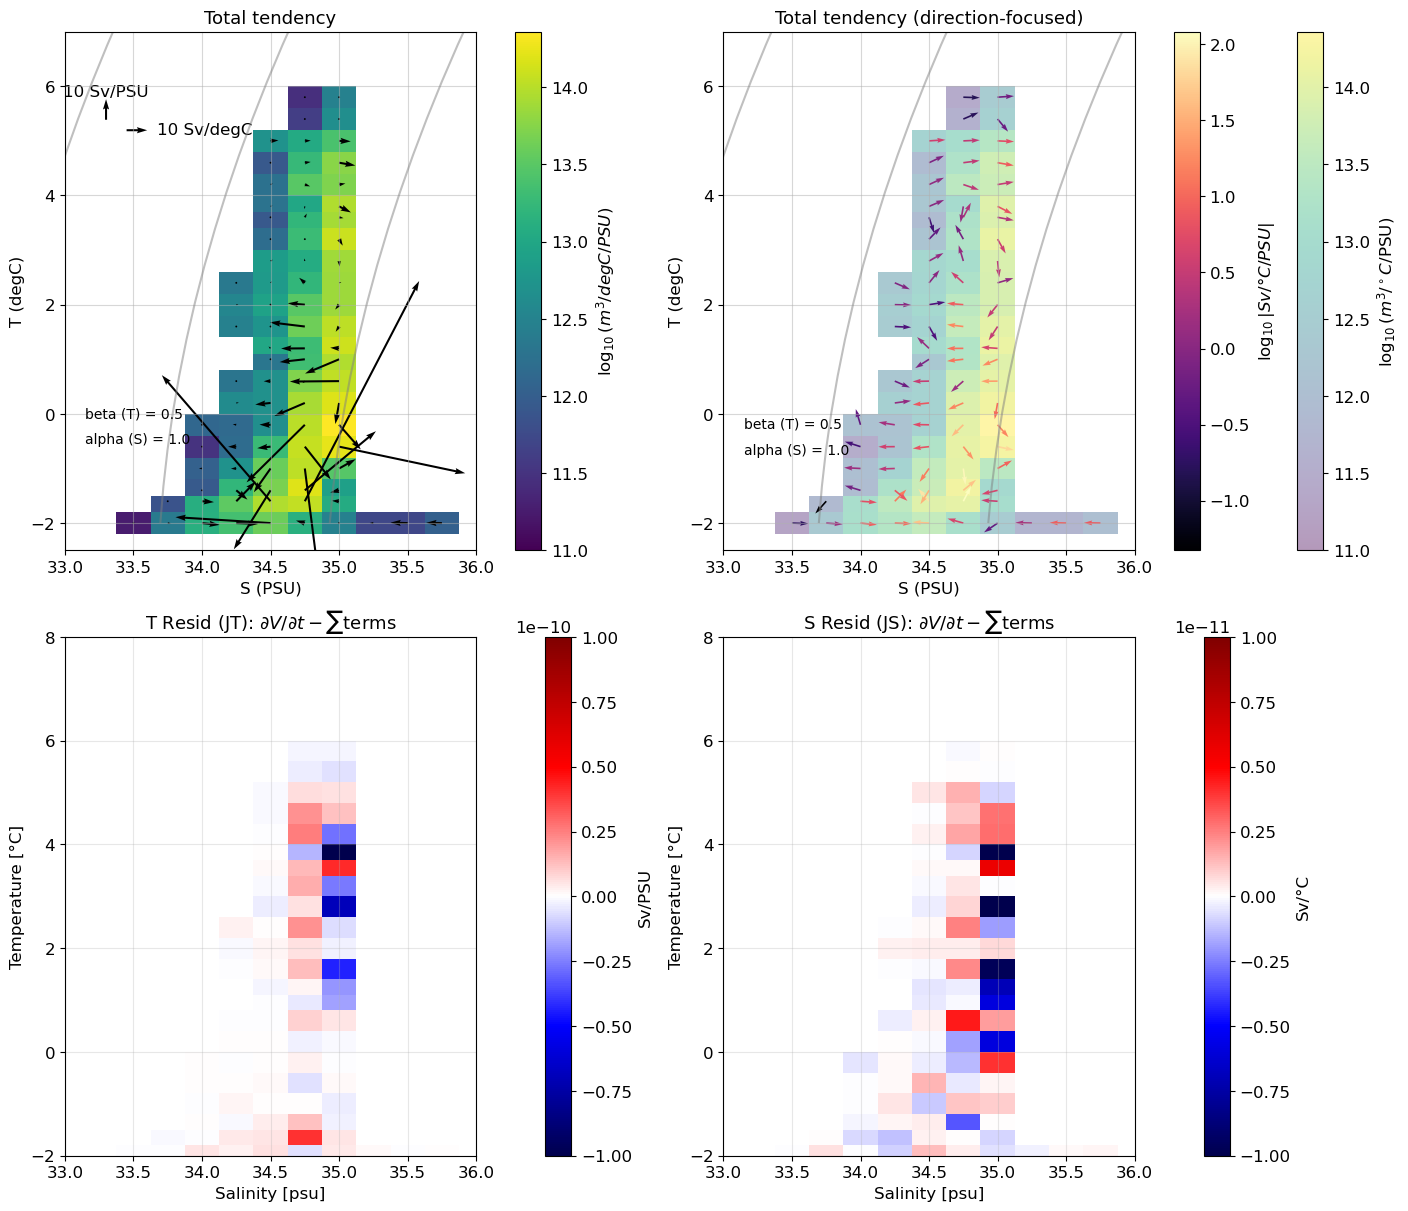

In [115]:
# 2x2 figure:
# top-left  = original quiver plot
# top-right = direction-normalized quiver colored by log10(|J|)
# bottom-left  = JT residual
# bottom-right = JS residual

alpha = 1.0
beta = 0.5
arrow_length = 10
U = arrow_length
scale = 2e2
step = 1

xlims = np.array([33, 36])
ylims = np.array([-2.5, 7])

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# ==================================================
# Top-left: original quiver plot
# ==================================================
ax = axes[0, 0]

cb1 = ax.pcolormesh(Sbin2, Tbin2, np.log10(vol_mesh.T), cmap='viridis', vmin=11)

U1, V1 = Jx_tend.T.copy(), Jy_tend.T.copy()
U1[U1 == 0] = np.nan
V1[V1 == 0] = np.nan
U1 = U1 * alpha
V1 = V1 * beta

q1 = ax.quiver(Sbin2, Tbin2, U1, V1, width=0.005, scale=scale)
plt.colorbar(cb1, ax=ax, label=r'$\log_{10}(m^3/degC/PSU)$')

ax.set_title("Total tendency")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_xlabel("S (PSU)")
ax.set_ylabel("T (degC)")
ax.grid(alpha=0.5)

ax.quiverkey(q1, X=0.2, Y=0.81, U=U, label=f"{U} Sv/degC", labelpos='E')
ax.quiverkey(
    q1, X=0.1, Y=0.85, U=U,
    label=f"{U} Sv/PSU", angle=90, labelpos='N', coordinates='axes'
)

ax.text(
    0.05, 0.2, f'alpha (S) = {alpha}',
    transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom'
)
ax.text(
    0.05, 0.25, f'beta (T) = {beta}',
    transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom'
)

cs = ax.contour(
    si, ti, dens2,
    colors="grey", zorder=2, alpha=0.5,
    levels=np.arange(16, 32, 1)
)
ax.clabel(cs, fontsize=10, inline=False, fmt="%.f")

# ==================================================
# Top-right: log-magnitude quiver plot
# ==================================================
ax = axes[0, 1]

cb2 = ax.pcolormesh(
    Sbin2, Tbin2, np.log10(vol_mesh.T),
    cmap='viridis', vmin=11,alpha=0.4
)
plt.colorbar(cb2, ax=ax, label=r'$\log_{10}(m^3/^\circ C/\mathrm{PSU})$')

U2 = Jx_tend.T.copy() * alpha
V2 = Jy_tend.T.copy() * beta

mag = np.sqrt(U2**2 + V2**2)
Udir = U2 / mag
Vdir = V2 / mag

Udir[~np.isfinite(Udir)] = np.nan
Vdir[~np.isfinite(Vdir)] = np.nan
mag[mag == 0] = np.nan

q2 = ax.quiver(
    Sbin2[::step, ::step],
    Tbin2[::step, ::step],
    Udir[::step, ::step],
    Vdir[::step, ::step],
    np.log10(mag[::step, ::step]),
    cmap='magma',
    width=0.004,
    scale=25
)
plt.colorbar(q2, ax=ax, label=r'$\log_{10}|Sv/°C/PSU|$')

ax.set_title(r"Total tendency (direction-focused)")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_xlabel("S (PSU)")
ax.set_ylabel("T (degC)")
ax.grid(alpha=0.5)

ax.text(
    0.05, 0.18, f'alpha (S) = {alpha}',
    transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom'
)
ax.text(
    0.05, 0.23, f'beta (T) = {beta}',
    transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom'
)

cs = ax.contour(
    si, ti, dens2,
    colors="grey", zorder=2, alpha=0.5,
    levels=np.arange(16, 32, 1)
)
ax.clabel(cs, fontsize=10, inline=False, fmt="%.f")

# ==================================================
# Bottom-left: JT residual
# ==================================================
ax = axes[1, 0]

LHS_T = termsT_TS['tend']
RHS_T = (
    termsT_TS['ADVh'] + termsT_TS['ADVr'] +
    termsT_TS['DFhT'] + termsT_TS['DFrT'] +
    termsT_TS['surf'] + termsT_TS['KPP']
)
RHS_T *= 1e-6

cb3 = ax.pcolormesh(
    Sbin2, Tbin2, (LHS_T - RHS_T).T,
    cmap='seismic', vmin=-1e-11, vmax=1e-11
)
plt.colorbar(cb4, ax=ax, label='Sv/PSU')

ax.set_title(r'T Resid (JT): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)
ax.grid(alpha=0.3)

# ==================================================
# Bottom-right: JS residual
# ==================================================
ax = axes[1, 1]

LHS_S = termsS_TS['tend']
RHS_S = (
    termsS_TS['ADVh'] + termsS_TS['ADVr'] +
    termsS_TS['DFhS'] + termsS_TS['DFrS'] +
    termsS_TS['surf'] + termsS_TS['KPP']
)
RHS_S *= 1e-6

cb4 = ax.pcolormesh(
    Sbin2, Tbin2, (LHS_S - RHS_S).T,
    cmap='seismic', vmin=-1e-10, vmax=1e-10
)
plt.colorbar(cb3, ax=ax, label='Sv/°C')

ax.set_title(r'S Resid (JS): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)
ax.grid(alpha=0.3)


plt.savefig("J_andresid_miniasteBS.png",dpi=300)
plt.show()

# plot the divergences

In [116]:
ttend = termsT_TS['tend']
stend = termsS_TS['tend']
ttend[np.isnan(ttend)] = 0
stend[np.isnan(stend)] = 0

In [117]:
# we still need the gateway contributions, binned at the gate face THETA/SALT

T_keys = list(termsT_TS.keys())
S_keys = list(termsS_TS.keys())

# total tendency
dVdt = get_div(ttend, stend, dT_centers, dS_centers)

# example single term
divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_centers, dS_centers)

divDFh = get_div(termsT_TS['DFhT'], termsS_TS['DFhS'], dT_centers, dS_centers)


# internal = sum of terms at positions 1,2,3,5
internal_inds = [1, 2, 3, 5]

divint = sum(
    get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_centers, dS_centers)
    for i in internal_inds
)

# surface = term at position 4
surface_ind = 4
divsurf = get_div(termsT_TS[T_keys[surface_ind]],termsS_TS[S_keys[surface_ind]],dT_centers,dS_centers)

In [118]:
BSO_div = get_div(MsumT['BSO_TS'], MsumS['BSO_TS'], dT_centers, dS_centers)
FJNZ_div = get_div(MsumT['FJNZ_TS'], MsumS['FJNZ_TS'], dT_centers, dS_centers)
SPFJ_div = get_div(MsumT['SPFJ_TS'], MsumS['SPFJ_TS'], dT_centers, dS_centers)
NZRU_div = get_div(MsumT['NZRU_TS'], MsumS['NZRU_TS'], dT_centers, dS_centers)
Msum_div = get_div(MsumT['Msum_TS'], MsumS['Msum_TS'], dT_centers, dS_centers)

In [119]:
# BSO_div = get_div(MsumT['BSO_TS'], MsumS['BSO_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, BSO_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('BSO TS Diagram')
# plt.show()

# FJNZ_div = get_div(MsumT['FJNZ_TS'], MsumS['FJNZ_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, FJNZ_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('FJNZ TS Diagram')
# plt.show()

# SPFJ_div = get_div(MsumT['SPFJ_TS'], MsumS['SPFJ_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, SPFJ_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('SPFJ TS Diagram')
# plt.show()

# NZRU_div = get_div(MsumT['NZRU_TS'], MsumS['NZRU_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, NZRU_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('NZRU TS Diagram')
# plt.show()

# Msum_div = get_div(MsumT['Msum_TS'], MsumS['Msum_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, Msum_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('Msum TS Diagram')
# plt.show()

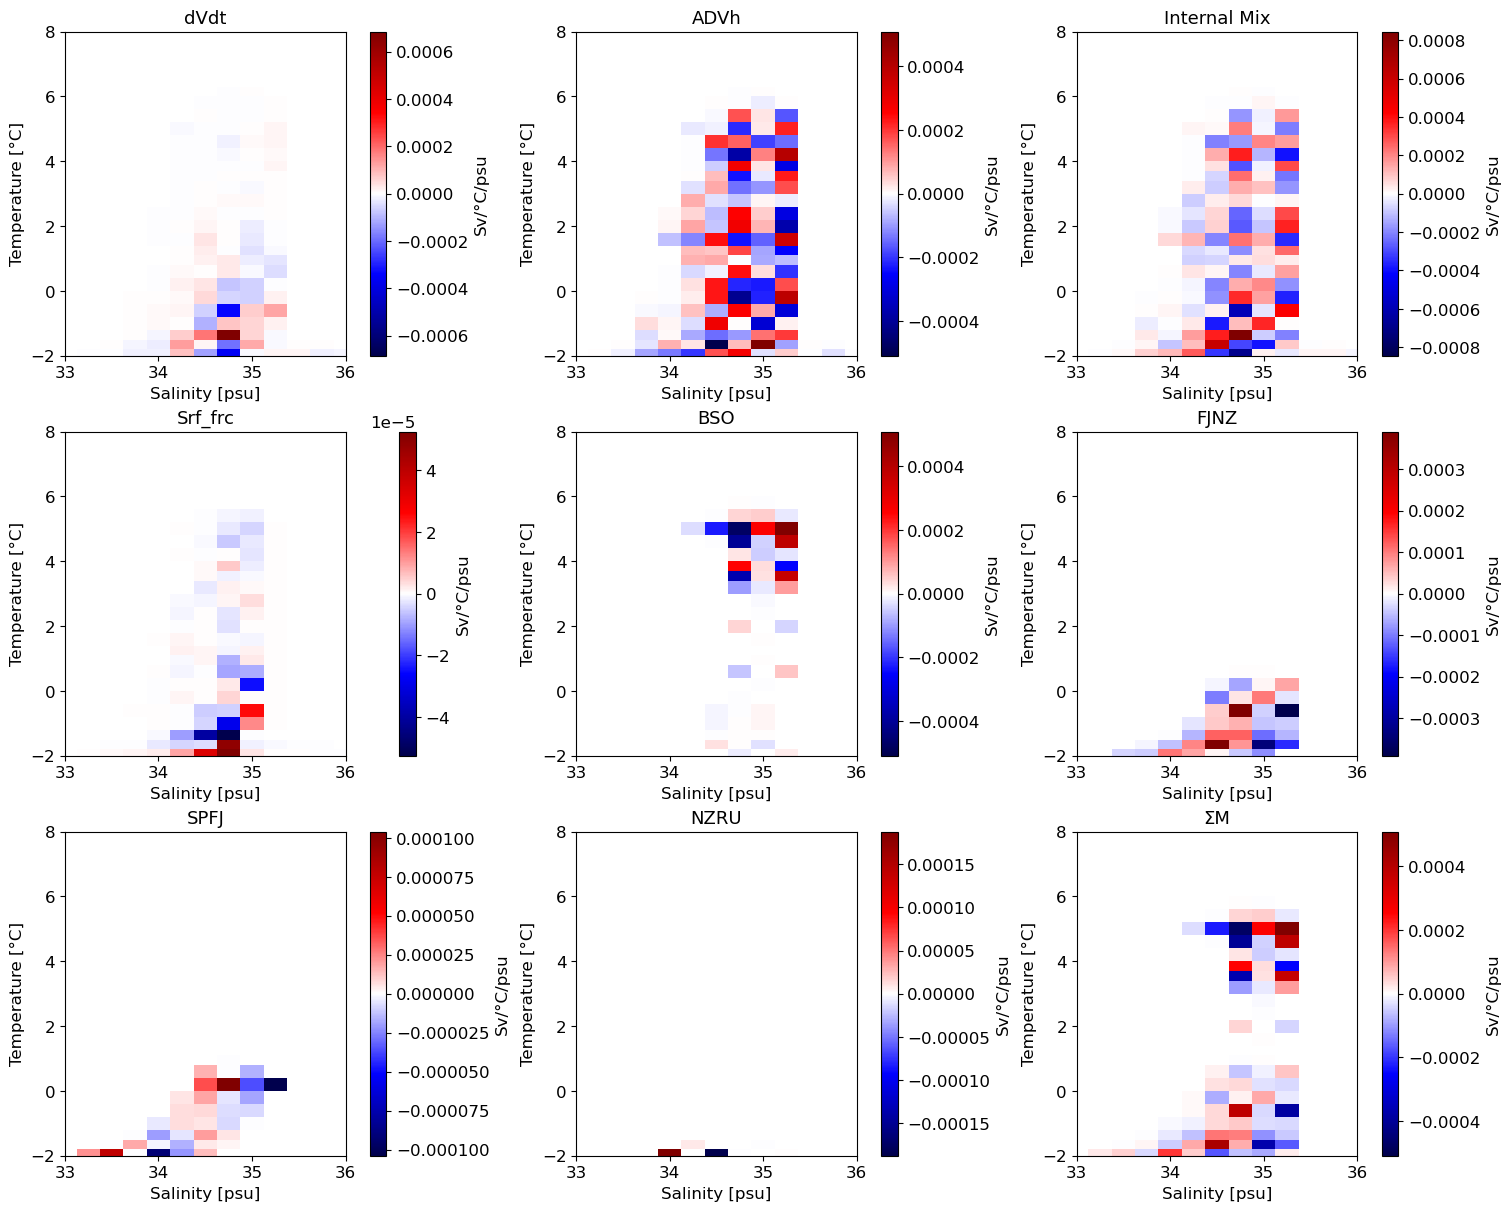

In [120]:
# plot the other terms against this difference
plot_dict = {
    'dVdt': dVdt,
    'ADVh': divADVh*1e-6,
    'Internal Mix': divint*1e-6,
    'Srf_frc': divsurf*1e-6,
    'BSO': BSO_div*1e-6,
    'FJNZ': FJNZ_div*1e-6,
    'SPFJ': SPFJ_div*1e-6,
    'NZRU': NZRU_div*1e-6,
    'ΣM': Msum_div*1e-6,
}

nplots = len(plot_dict)
ncols = 3
nrows = (nplots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

for ax, (name, div) in zip(axes, plot_dict.items()):
    a = div.copy()
    a[a==0] = np.nan
    vlev = np.nanmax(a)
    pcm = ax.pcolormesh(Sbin3, Tbin3, a.T, shading='auto',cmap='seismic',vmin=-vlev,vmax=vlev)
    ax.set_xlabel('Salinity [psu]')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(name)
    ax.set_xlim(33,36)
    ax.set_ylim(-2,8)
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('Sv/°C/psu')

# remove unused axes
for ax in axes[len(plot_dict):]:
    fig.delaxes(ax)

plt.show()

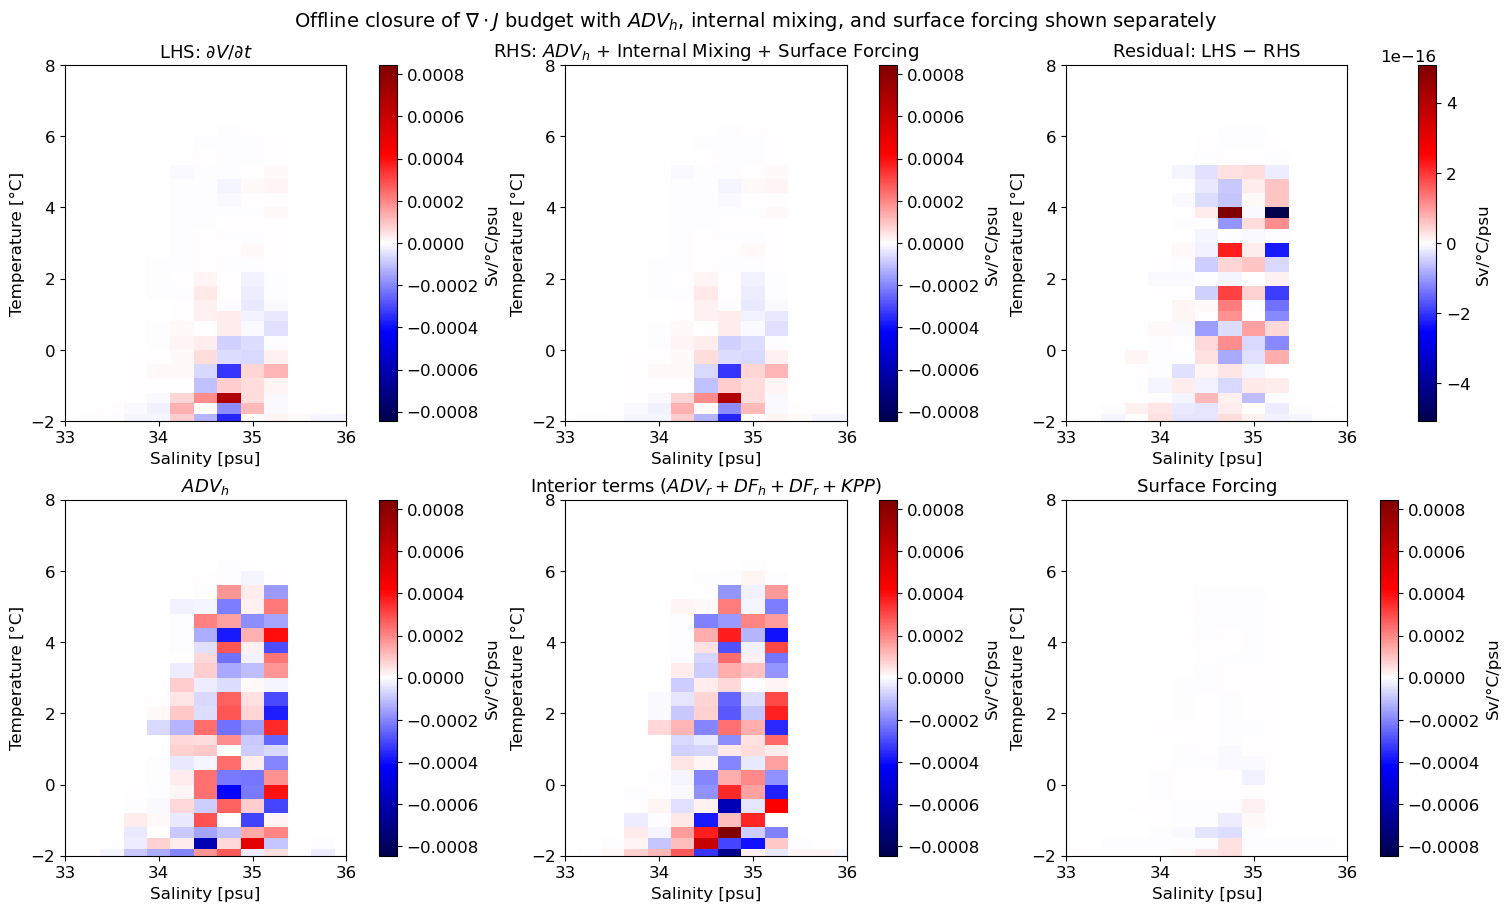

In [151]:
# check the closure of the offline terms without gates
# separate ADVh, Internal Mixing, and Surface Forcing explicitly
# save figure

lhs = dVdt.copy()
advh = divADVh * 1e-6
internal = divint * 1e-6
surface = divsurf * 1e-6
rhs = advh + internal + surface
resid = lhs - rhs

plot_dict = {
    r'LHS: $\partial V/\partial t$': lhs,
    r'RHS: $ADV_h$ + Internal Mixing + Surface Forcing': rhs,
    r'Residual: LHS $-$ RHS': resid,
    r'$ADV_h$': advh,
    r'Interior terms ($ADV_r + DF_h + DF_r + KPP$)': internal,
    r'Surface Forcing': surface,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.flatten()

# use a shared color scale for all physical terms except the residual
main_fields = [
    np.nan_to_num(lhs, nan=0.0),
    np.nan_to_num(advh, nan=0.0),
    np.nan_to_num(internal, nan=0.0),
    np.nan_to_num(surface, nan=0.0),
    np.nan_to_num(rhs, nan=0.0),
]
vlev_main = np.nanmax(np.abs(np.stack(main_fields)))
if not np.isfinite(vlev_main) or vlev_main == 0:
    vlev_main = 1.0

vlev_resid = np.nanmax(np.abs(np.nan_to_num(resid, nan=0.0)))
if not np.isfinite(vlev_resid) or vlev_resid == 0:
    vlev_resid = 1.0

for ax, (title, field) in zip(axes, plot_dict.items()):
    a = field.copy()
    a[a == 0] = np.nan

    this_vlev = vlev_resid if "Residual" in title else vlev_main

    pcm = ax.pcolormesh(
        Sbin3, Tbin3, a.T,
        shading='auto',
        cmap='seismic',
        vmin=-this_vlev,
        vmax=this_vlev
    )
    ax.set_xlabel('Salinity [psu]')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(title)
    ax.set_xlim(33, 36)
    ax.set_ylim(-2, 8)

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('Sv/°C/psu')

fig.suptitle(
    r'Offline closure of $\nabla \cdot J$ budget with $ADV_h$, internal mixing, and surface forcing shown separately',
    fontsize=14
)

outname = "offline_divJ_closure_split_terms.png"
plt.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()

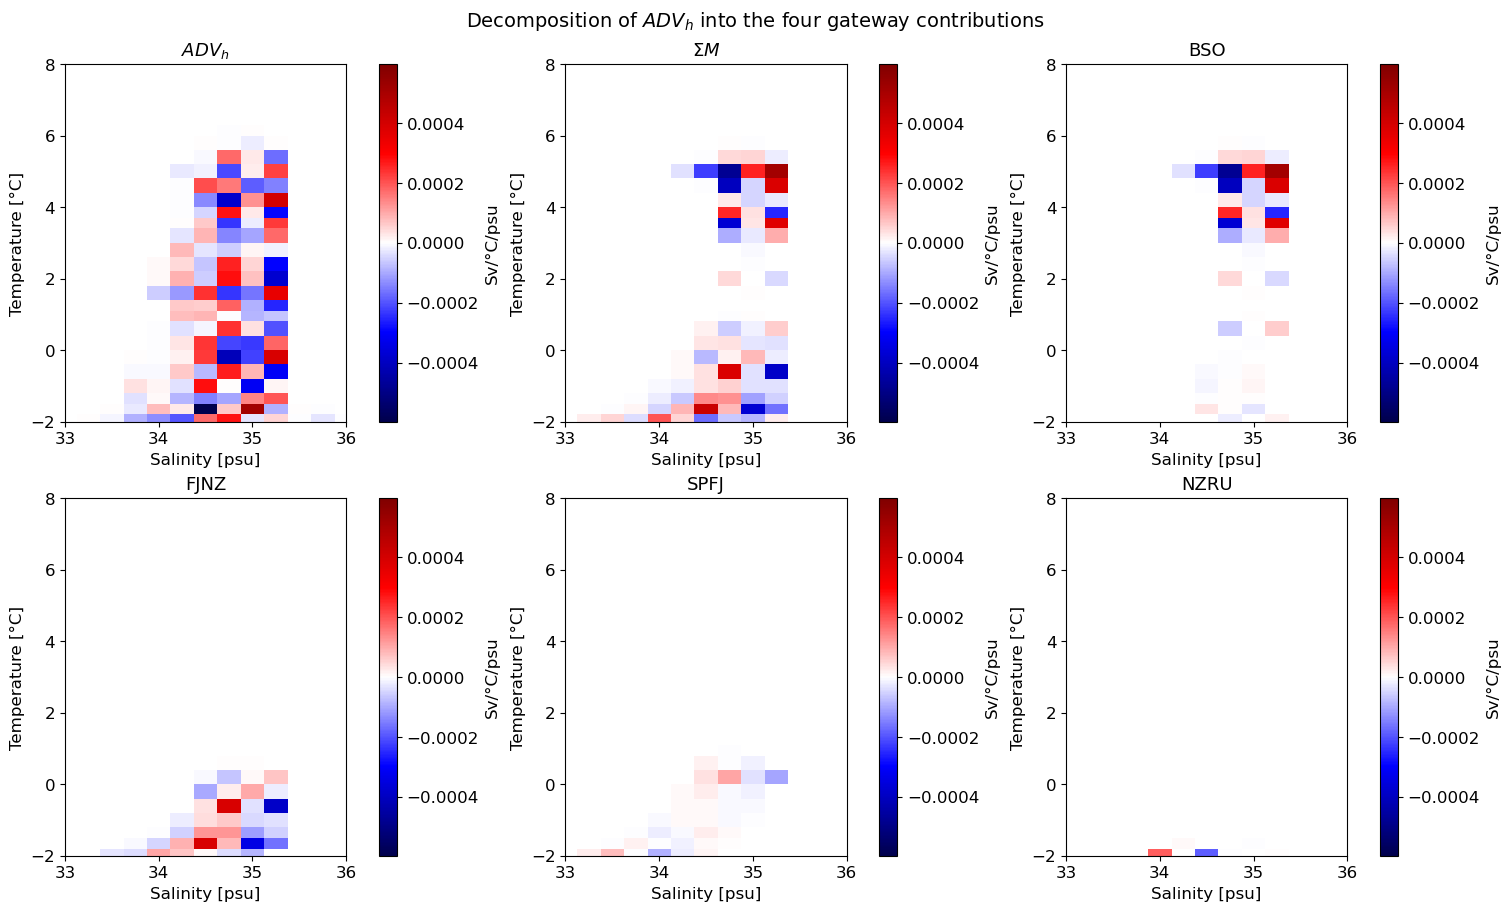

In [152]:
# show ADVh and its decomposition into the four gateway contributions

ADVh = divADVh * 1e-6
BSO  = BSO_div  * 1e-6
FJNZ = FJNZ_div * 1e-6
SPFJ = SPFJ_div * 1e-6
NZRU = NZRU_div * 1e-6
Msum = Msum_div * 1e-6

plot_dict = {
    r'$ADV_h$': ADVh,
    r'$\Sigma M$': Msum,
    'BSO': BSO,
    'FJNZ': FJNZ,
    'SPFJ': SPFJ,
    'NZRU': NZRU,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.flatten()

# use a common scale for all panels so gate magnitudes are directly comparable
all_fields = [np.nan_to_num(arr, nan=0.0) for arr in plot_dict.values()]
vlev = np.nanmax(np.abs(np.stack(all_fields)))
if not np.isfinite(vlev) or vlev == 0:
    vlev = 1.0

for ax, (name, field) in zip(axes, plot_dict.items()):
    a = field.copy()
    a[a == 0] = np.nan

    pcm = ax.pcolormesh(
        Sbin3, Tbin3, a.T,
        shading='auto',
        cmap='seismic',
        vmin=-vlev,
        vmax=vlev
    )
    ax.set_xlabel('Salinity [psu]')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(name)
    ax.set_xlim(33, 36)
    ax.set_ylim(-2, 8)

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('Sv/°C/psu')

fig.suptitle(
    r'Decomposition of $ADV_h$ into the four gateway contributions',
    fontsize=14
)

plt.savefig("ADVh_four_gates_decomposition.png", dpi=300, bbox_inches='tight')
plt.show()

## We still need to compare this against the online J term

In [121]:
# the overall tend here is different for both. and not sure why. Let's plot an example convergence of T S diagrams from layers
# load the ifldT terms we need from the THETA field
# we are copying from Jy terms

# setTS_Ttend = ['LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS', 'LTto_TS']

# check these from the miniaste if same order
setTS_Ttend=parsemeta(dirlayers + "layers_TSjoint_Ttend_set1.0000000003.meta")["fldList"]
setTS_Ttend

setTS_Stend=parsemeta(dirlayers + "layers_TSjoint_Stend_set1.0000000003.meta")["fldList"]
# setTS_Stend

['LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS', 'LSto_TS']

In [124]:
setTS_Ttend

['LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS', 'LTto_TS']

In [125]:
# do the Jy term
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED
# JUST FOR SET1 HERE - NOT FOR SET 2
# 287 - should be indexing nt, ns, wetpoints
# T, S, wetpoints

Jy = {}
nbasin = "BarentsS"
Jy[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny, nx)
small = rac2d * hf2d

# map original layers names -> desired dictionary names
name_map_T = {
    'LaTs_TS': 'surf',
    'LaTh_TS': 'DFhT',
    'LaTz_TS': 'DFrT',
    'LTha_TS': 'ADVh',
    'LTza_TS': 'ADVr',
    'LTto_TS': 'tend',
}

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jy[nbasin][t] = {}
    Jy[nbasin][t]['G_T'] = {}

    # now loop through the terms and add these to the dictionary
    for i in range(len(setTS_Ttend) - 1, -1, -1):
        print(i)

        orig_name = setTS_Ttend[i]
        save_name = name_map_T[orig_name]

        # read the file and apply masking
        filename = dirlayers + f"layers_TSjoint_Ttend_set1.{t}.data"
        tmp = read_float64_skip(filename, LwetC2d * (nS - 1) * (nT - 1), i)
        tmp = np.reshape(tmp, (nT - 1, nS - 1, LwetC2d))
        tmp = tmp * np.tile(small[np.newaxis, np.newaxis, :], (nT - 1, nS - 1, 1)) * ffac

        # if at end of loop
        if i == len(setTS_Ttend) - 1:
            f = np.nansum(tmp, axis=2)
            f = np.nansum(f * binwidthS1)

        # total tendency and residual
        if orig_name == 'LTto_TS':
            residT = tmp.copy()
        elif orig_name in {'LaTs_TS', 'LaTh_TS', 'LaTz_TS', 'LTha_TS', 'LTza_TS'}:
            residT -= tmp

        tmp1 = np.nansum(tmp[:, :, iwet_mine], axis=2)   # shape (nT-1, nS-1)
        tmp2 = np.nansum(tmp1 * binwidthS1, axis=1)      # shape (nT-1,)

        Jy[nbasin][t][save_name] = tmp1
        Jy[nbasin][t]['G_T'][save_name] = tmp2

        del tmp, tmp1, tmp2

    myresid = np.nansum(residT[:, :, iwet_mine], axis=2)
    Jy[nbasin][t]["residT"] = myresid
    Jy[nbasin][t]["G_T"]["residT"] = np.nansum(
        Jy[nbasin][t]["residT"] * binwidthS1, axis=1
    )

    print()

# set units and labels
Jy["unit"] = "m/s/psu"

0000000004
5
4
3
2
1
0



In [126]:
# I think we need to redefine J with a single cell or a very small mask (maybe one cell)
# DO NOT RUN IF HAS ALREADY BEEN CALCULATED

Jx = {}
Jx[nbasin] = {}

rac = mygrid['RAC']
hf1 = hf1.reshape(ny, nx)

# map original layers names -> desired dictionary names
name_map_S = {
    'LaSs_TS': 'surf',
    'LaSh_TS': 'DFhS',
    'LaSz_TS': 'DFrS',
    'LSha_TS': 'ADVh',
    'LSza_TS': 'ADVr',
    'LSto_TS': 'tend',
}

# loop through the existing timesteps
for t in tsstr[1:]:
    print(t)
    Jx[nbasin][t] = {}
    Jx[nbasin][t]['G_S'] = {}

    # loop through the diagnostics
    for i in range(len(setTS_Stend) - 1, -1, -1):
        orig_name = setTS_Stend[i]
        save_name = name_map_S[orig_name]

        filename = dirlayers + f"layers_TSjoint_Stend_set1.{t}.data"
        tmp = read_float64_skip(filename, LwetC2d * (nS - 1) * (nT - 1), i)
        tmp = np.reshape(tmp, (nT - 1, nS - 1, LwetC2d))
        print(tmp.shape)

        small = rac2d * hf2d
        tmp = tmp * np.tile(small[np.newaxis, np.newaxis, :], (nT - 1, nS - 1, 1)) * ffac

        # initialize residual with total tendency, then subtract component terms
        if orig_name == 'LSto_TS':
            residS = tmp.copy()
        elif orig_name in {'LaSs_TS', 'LaSh_TS', 'LaSz_TS', 'LSha_TS', 'LSza_TS'}:
            residS -= tmp

        # sum over geographic wet points -> shape (nT-1, nS-1)
        tmp1 = np.nansum(tmp[:, :, iwet_mine], axis=2)

        # integrate over T for G_S
        thisbinwidthT1 = np.tile(binwidthT1[:, np.newaxis], (1, nS - 1))   # shape (nT-1, nS-1)
        tmp2 = np.nansum(tmp1 * thisbinwidthT1, axis=0)                     # shape (nS-1,)

        print(orig_name)
        Jx[nbasin][t][save_name] = tmp1
        Jx[nbasin][t]['G_S'][save_name] = tmp2

        del tmp, tmp1, tmp2

    # residual
    tmp1 = np.nansum(residS[:, :, iwet_mine], axis=2)                       # shape (nT-1, nS-1)
    mytileT1 = np.tile(binwidthT1[:, np.newaxis], (1, nS - 1))              # shape (nT-1, nS-1)
    tmp2 = np.nansum(tmp1 * mytileT1, axis=0)                               # shape (nS-1,)

    Jx[nbasin][t]["residS"] = tmp1
    Jx[nbasin][t]["G_S"]["residS"] = tmp2

# set units and labels
Jx["descr"] = "m/s/degC"

0000000004
(111, 111, 40500)
LSto_TS
(111, 111, 40500)
LSza_TS
(111, 111, 40500)
LSha_TS
(111, 111, 40500)
LaSz_TS
(111, 111, 40500)
LaSh_TS
(111, 111, 40500)
LaSs_TS


In [133]:
termsT_TS.keys()

dict_keys(['ADVh', 'ADVr', 'DFhT', 'DFrT', 'surf', 'KPP', 'tend'])

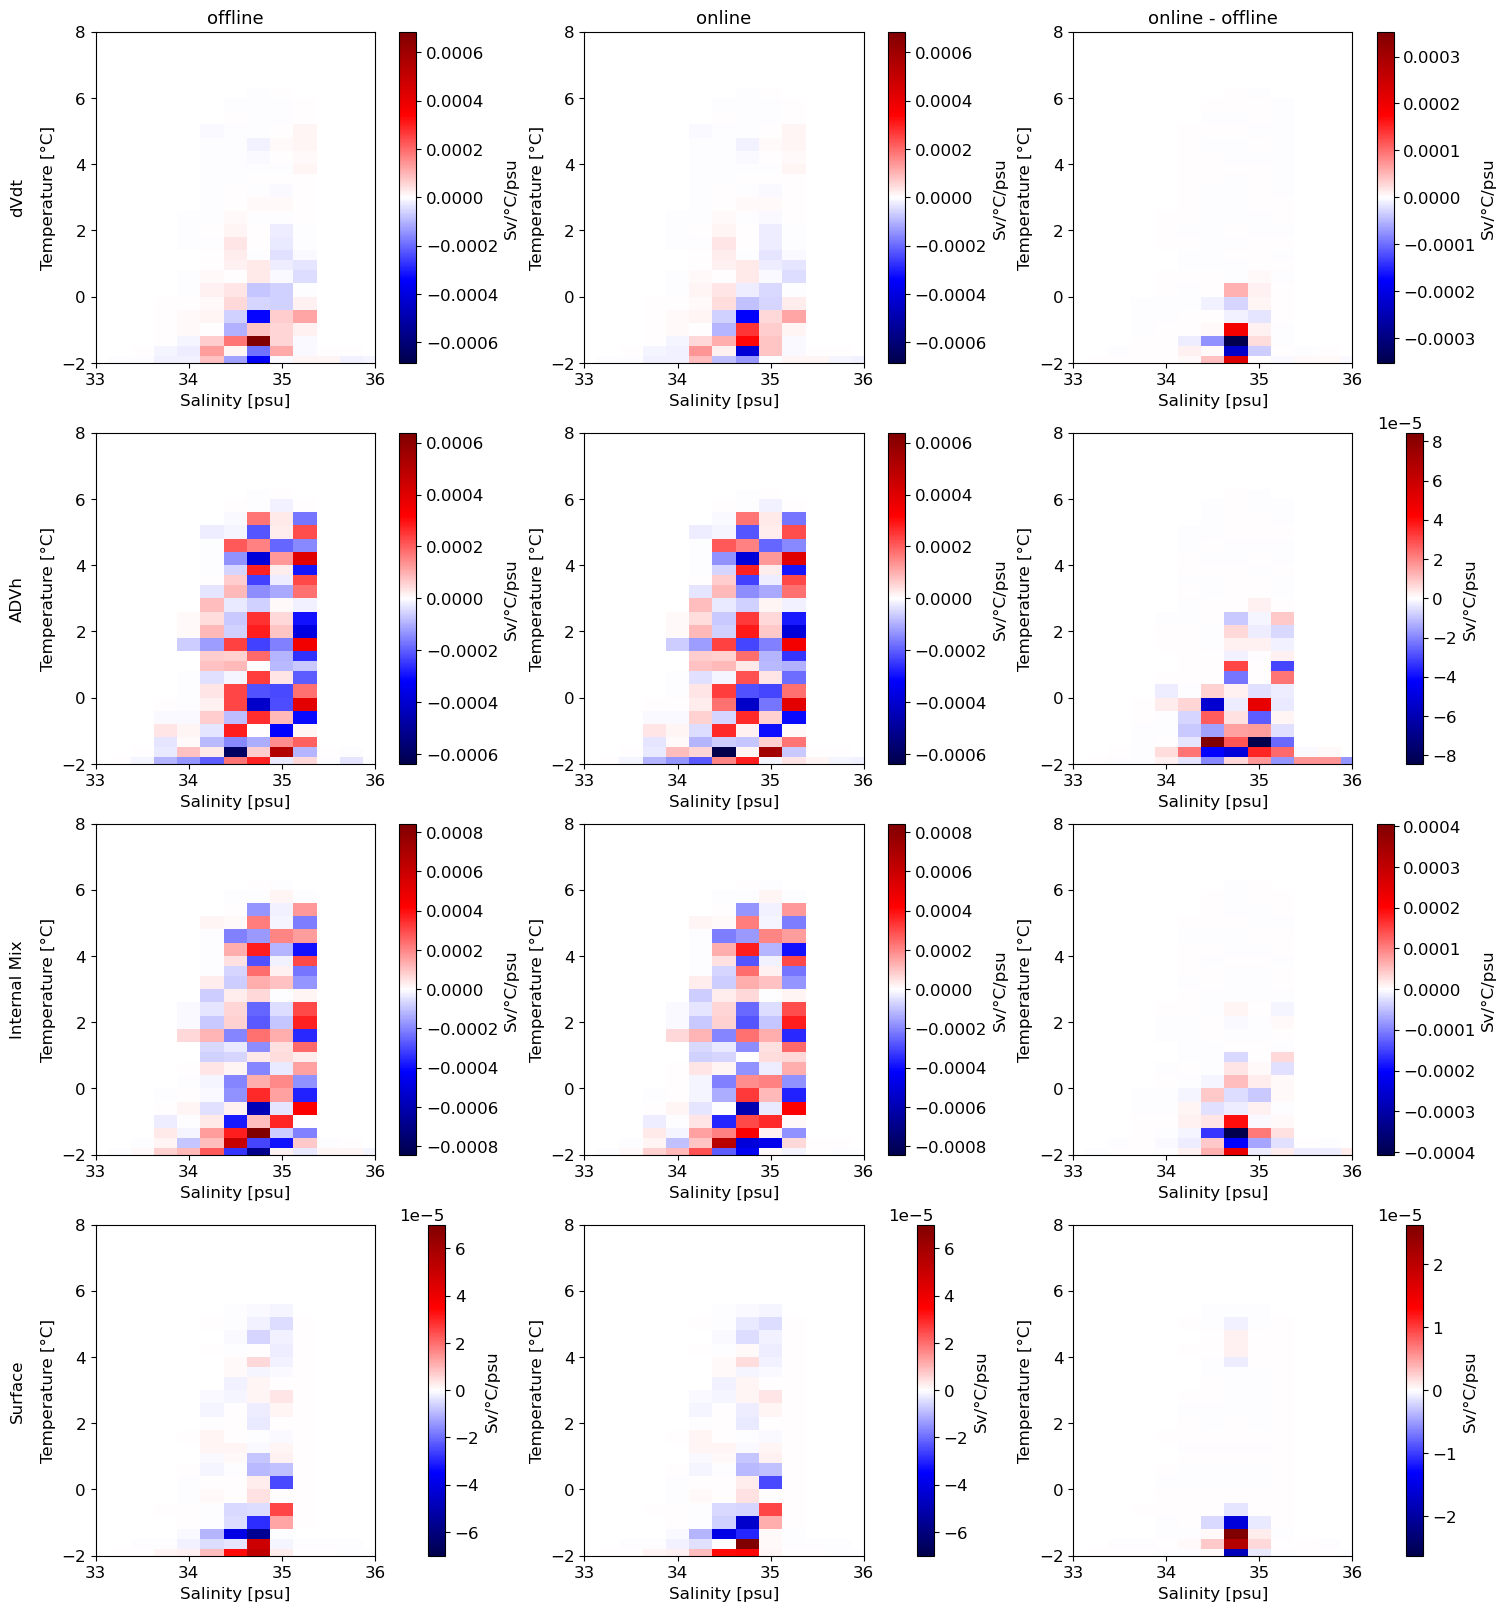

In [153]:
# grouped offline divergences
dVdt_off = get_div(termsT_TS['tend'], termsS_TS['tend'], dT_centers, dS_centers) #* 1e-6
divADVh_off = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_centers, dS_centers) * 1e-6
divDFh_off = get_div(termsT_TS['DFhT'], termsS_TS['DFhS'], dT_centers, dS_centers) * 1e-6

divint_off = (
    get_div(termsT_TS['DFhT'], termsS_TS['DFhS'], dT_centers, dS_centers) +
    get_div(termsT_TS['DFrT'], termsS_TS['DFrS'], dT_centers, dS_centers) +
    get_div(termsT_TS['ADVr'], termsS_TS['ADVr'], dT_centers, dS_centers) +
    get_div(termsT_TS['KPP'],  termsS_TS['KPP'],  dT_centers, dS_centers)
) * 1e-6

divsurf_off = get_div(termsT_TS['surf'], termsS_TS['surf'], dT_centers, dS_centers) * 1e-6

# ONLINE ONES ALREADY IN SV
dVdt_on = get_div(Jy[nbasin][t]['tend'], Jx[nbasin][t]['tend'], dT_centers, dS_centers)
divADVh_on = get_div(Jy[nbasin][t]['ADVh'], Jx[nbasin][t]['ADVh'], dT_centers, dS_centers)
divDFh_on = get_div(Jy[nbasin][t]['DFhT'], Jx[nbasin][t]['DFhS'], dT_centers, dS_centers)

divint_on = (
    get_div(Jy[nbasin][t]['DFhT'], Jx[nbasin][t]['DFhS'], dT_centers, dS_centers) +
    get_div(Jy[nbasin][t]['DFrT'], Jx[nbasin][t]['DFrS'], dT_centers, dS_centers) +
    get_div(Jy[nbasin][t]['ADVr'], Jx[nbasin][t]['ADVr'], dT_centers, dS_centers)
)

divsurf_on = get_div(Jy[nbasin][t]['surf'], Jx[nbasin][t]['surf'], dT_centers, dS_centers)

# grouped differences
dVdt_diff   = dVdt_on   - dVdt_off
divADVh_diff = divADVh_on - divADVh_off
divDFh_diff  = divDFh_on  - divDFh_off
divint_diff  = divint_on  - divint_off
divsurf_diff = divsurf_on - divsurf_off

# organize for plotting: rows = grouped term, cols = offline / online / difference
plot_groups = {
    'dVdt': [dVdt_off, dVdt_on, dVdt_diff],
    'ADVh': [divADVh_off, divADVh_on, divADVh_diff],
    'Internal Mix': [divint_off, divint_on, divint_diff],
    'Surface': [divsurf_off, divsurf_on, divsurf_diff],
}

col_titles = ['offline', 'online', 'online - offline']

nrows = len(plot_groups)
ncols = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True)

# handle the case of a single row
if nrows == 1:
    axes = np.array([axes])

for i, (row_name, arrs) in enumerate(plot_groups.items()):
    off, on, diff = [a.copy() for a in arrs]

    off[off == 0] = np.nan
    on[on == 0] = np.nan
    diff[diff == 0] = np.nan

    # use shared scale for offline/online, separate one for diff
    vmain = np.nanmax(np.abs(np.array([
        np.nan_to_num(off, nan=0.0),
        np.nan_to_num(on, nan=0.0)
    ])))
    if not np.isfinite(vmain) or vmain == 0:
        vmain = 1.0

    vdiff = np.nanmax(np.abs(np.nan_to_num(diff, nan=0.0)))
    if not np.isfinite(vdiff) or vdiff == 0:
        vdiff = 1.0

    arrays = [off, on, diff]
    scales = [vmain, vmain, vdiff]

    for j in range(ncols):
        ax = axes[i, j]
        pcm = ax.pcolormesh(
            Sbin3, Tbin3, arrays[j].T,
            shading='auto',
            cmap='seismic',
            vmin=-scales[j],
            vmax=scales[j]
        )

        if i == 0:
            ax.set_title(col_titles[j])

        ax.set_xlabel('Salinity [psu]')
        ax.set_ylabel('Temperature [°C]')
        ax.set_xlim(33, 36)
        ax.set_ylim(-2, 8)

        # row label on the left-most panel
        if j == 0:
            ax.text(
                -0.28, 0.5, row_name,
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='center',
                fontsize=12
            )

        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label('Sv/°C/psu')

plt.savefig("miniASTE_compare_off_online.png",dpi=300)
plt.show()